# Project: Antarctica Freeboard Calculation


## A. ICESat-2 ATL07 Data Download

For each tide gauge station, search and download ICESat-2 ATL07 granules that pass within a specified radius.

**Antarctica Tide Gauge Stations:**
- ROBT (-77.0333, 163.1833)
- SCOT (-77.8500, 166.7667)


### A1. Install Dependencies

Run once if not already installed

!pip install icepyx earthaccess h5py numpy pandas ipykernel

Note:
1. version of icepyx should be 1.3.0 or higher;

2. Please let NASA Earthdata give permission to NSIDC:

    (1) login: urs.earthdata.nasa.gov;

    (2) click your profile;

    (3) Applications → Authorized Apps;

    (4) check if list contains NSIDC_DATAPOOL_OPS or NSIDC_DATAPOOL_OPS_HTTPS_ALT

    if not, click APPROVE MORE APPLICATIONS to add this two.

### A2. Imports

In [12]:
import icepyx as ipx
import earthaccess
import os
import math
import pandas as pd
from datetime import date

### A3. Configuration

In [13]:
# Root output directory (each station gets its own subfolder)
OUTPUT_DIR = r'/media/pzhang27/Extreme SSD/Freeboard_input_data/ATL07'

# Search radius around each station (km). Default = 5 km.
SEARCH_RADIUS_KM = 5.0

# Time range
DATE_START = '2018-10-13'   # ICESat-2 first available date
DATE_END   = date.today().strftime('%Y-%m-%d')

# ICESat-2 product
PRODUCT = 'ATL07'

# Tide gauge stations:  name -> (lat, lon)
STATIONS = {
    'ROBT': (-77.0333, 163.1833),
    'SCOT': (-77.8500, 166.7667),
}


### A4. NASA Earthdata Login

In [14]:
# Authenticate with NASA Earthdata.
auth = earthaccess.login(strategy='interactive', persist=True)
print('Login successfully:',auth.authenticated)

Login successfully: True


### A5. Determine radius to bounding box

In [15]:
def km_to_bbox(lat, lon, radius_km):
    """
    Return [lon_min, lat_min, lon_max, lat_max] for a square bounding box
    centered on (lat, lon) with half-side = radius_km.
    """
    delta_lat = radius_km / 111.0
    delta_lon = radius_km / (111.0 * math.cos(math.radians(lat)))
    return [
        round(lon - delta_lon, 6),
        round(lat - delta_lat, 6),
        round(lon + delta_lon, 6),
        round(lat + delta_lat, 6),
    ]


### A6. Query granules for all stations

In [16]:
station_results = {}   # station_name -> dict with query + granule list
summary_rows    = []

for station, (lat, lon) in STATIONS.items():
    print(f'\n--- {station}  (lat={lat}, lon={lon}) ---')

    bbox = km_to_bbox(lat, lon, SEARCH_RADIUS_KM)
    print(f'  Bounding box [lon_min, lat_min, lon_max, lat_max]: {bbox}')

    try:
        region = ipx.Query(
            product        = PRODUCT,
            spatial_extent = bbox,
            date_range     = [DATE_START, DATE_END],
        )

        # avail_granules(ids=True) returns (name_list, url_list)
        granule_info  = region.avail_granules(ids=True)
        granule_names = granule_info[0]
        print(f'  Found {len(granule_names)} granule(s)')

        station_results[station] = {
            'query'        : region,
            'granule_names': granule_names,
            'lat'          : lat,
            'lon'          : lon,
            'bbox'         : bbox,
        }

        for name in granule_names:
            # Filename pattern: ATL07-01_YYYYMMDDHHMMSS_TTTTCCSS_VVV_NN.h5
            try:
                date_str = name.split('_')[1][:8]   # YYYYMMDD
                acq_date = pd.to_datetime(date_str, format='%Y%m%d').date()
            except Exception:
                acq_date = 'unknown'
            summary_rows.append({
                'station' : station,
                'filename': name,
                'date'    : acq_date,
            })

    except Exception as e:
        print(f'  ERROR: {e}')
        station_results[station] = {'granule_names': [], 'error': str(e)}

print('\nQuery complete.')



--- ROBT  (lat=-77.0333, lon=163.1833) ---
  Bounding box [lon_min, lat_min, lon_max, lat_max]: [162.982551, -77.078345, 163.384049, -76.988255]
  Found 204 granule(s)

--- SCOT  (lat=-77.85, lon=166.7667) ---
  Bounding box [lon_min, lat_min, lon_max, lat_max]: [166.552681, -77.895045, 166.980719, -77.804955]
  Found 204 granule(s)

Query complete.


### A7. Downloading Summary 

In [17]:
df_summary = pd.DataFrame(summary_rows, columns=['station', 'filename', 'date'])
df_summary = df_summary.sort_values(['station', 'date']).reset_index(drop=True)

print(f'Total granules across all stations: {len(df_summary)}')
print()
print(df_summary.groupby('station')['filename'].count()
               .rename('granule_count').to_string())
df_summary


Total granules across all stations: 408

station
ROBT    204
SCOT    204


,station,filename,date
0,ROBT,ATL07-02_20181110134001_06560101_007_02.h5,2018-11-10
1,ROBT,ATL07-02_20181118022312_07710101_007_02.h5,2018-11-18
2,ROBT,ATL07-02_20181213120727_11590101_007_02.h5,2018-12-13
3,ROBT,ATL07-02_20181217005907_12130101_007_02.h5,2018-12-17
4,ROBT,ATL07-02_20181221005048_12740101_007_02.h5,2018-12-21
...,...,...,...
403,SCOT,ATL07-02_20251219223217_00853001_007_01.h5,2025-12-19
404,SCOT,ATL07-02_20260106083312_03513001_007_01.h5,2026-01-06
405,SCOT,ATL07-02_20260117210831_05273001_007_01.h5,2026-01-17
406,SCOT,ATL07-02_20260215194418_09693001_007_01.h5,2026-02-15


### A8. Downloading granules organised by station

Files are saved to `OUTPUT_DIR/<STATION_NAME>/`.  
Already-downloaded `.h5` files are skipped so the cell is safe to re-run.

In [18]:
for station, info in station_results.items():
    granule_names = info.get('granule_names', [])
    if not granule_names:
        print(f'[{station}] No granules found - skipping.')
        continue

    station_dir = os.path.join(OUTPUT_DIR, station)
    os.makedirs(station_dir, exist_ok=True)

    # Skip files already on disk  (resume-safe)
    existing    = {f for f in os.listdir(station_dir) if f.endswith('.h5')}
    to_download = [n for n in granule_names if n not in existing]

    print(f'\n--- {station}: {len(to_download)} to download '
          f'({len(existing)} already present) ---')

    if not to_download:
        print('  All files already present.')
        continue

    try:
        results = earthaccess.search_data(
            short_name     = PRODUCT,
            bounding_box   = tuple(info['bbox']),   # (lon_min, lat_min, lon_max, lat_max)
            temporal       = (DATE_START, DATE_END),
        )
        earthaccess.download(results, local_path=station_dir)
        print(f'  Download complete -> {station_dir}')
    except Exception as e: 
        print(f'  ERROR downloading {station}: {e}')

print('\nAll downloads finished.')



--- ROBT: 0 to download (530 already present) ---
  All files already present.

--- SCOT: 0 to download (555 already present) ---
  All files already present.

All downloads finished.


### A9. Verify downloaded files

In [19]:
verify_rows = []

for station in STATIONS:
    station_dir = os.path.join(OUTPUT_DIR, station)
    if not os.path.isdir(station_dir):
        verify_rows.append({'station': station, 'granules_queried': 0,
                            'files_downloaded': 0, 'path': '(not created)'})
        continue

    h5_files         = [f for f in os.listdir(station_dir) if f.endswith('.h5')]
    granules_queried = len(station_results.get(station, {}).get('granule_names', []))
    files_downloaded = len(h5_files)
    verify_rows.append({
        'station'         : station,
        'granules_queried': granules_queried,
        'files_downloaded': files_downloaded,
        'files_per_granule': round(files_downloaded / granules_queried, 1) if granules_queried else 0,
        'path'            : station_dir,
    })

df_verify = pd.DataFrame(verify_rows)
print(df_verify.to_string(index=False))


station  granules_queried  files_downloaded  files_per_granule                                                        path
   ROBT               204               530                2.6 /media/pzhang27/Extreme SSD/Freeboard_input_data/ATL07/ROBT
   SCOT               204               555                2.7 /media/pzhang27/Extreme SSD/Freeboard_input_data/ATL07/SCOT


## B. Process ICESat-2 ATL07- Extract ice-surface height and leads.

## B1.Extract the ice-surface height.

Extract `height_segment_height` from sample files of all three structural variants,
applying the following quality control filters:

| Level | Field | Filter |
|---|---|---|
| Granule | `qa_granule_pass_fail` | == 0 (pass) |
| Beam | `sc_orient` | selects strong beams only |
| Segment | `height_segment_quality` | == 1 (good) |
| Segment | `height_segment_type` | -1 = off_pointing, 0 = could, 1 = ice, 2~9 = lead |
| Segment | `height_segment_ssh_flag` | 0 = ice surface, 1 = sea surface (lead) , -1 = fill value|

**Strong beam mapping by `sc_orient`:**
- `sc_orient = 1` (Forward):  GT1R, GT2R, GT3R are strong
- `sc_orient = 0` (Backward): GT1L, GT2L, GT3L are strong

**sea_ice** = height_segment_ssh_flag == 0 && height_segment_type == 1
cause even height_segment_ssh_flag == 0, height_segment_type still could be -1, 0, 2-9 which should be ignored.

### B11. Define Height_extraction Function

In [20]:
# ── Strong beam lookup by sc_orient ──────────────────────────────────────
# sc_orient=1 (Forward):  GT1R, GT2R, GT3R are strong
# sc_orient=0 (Backward): GT1L, GT2L, GT3L are strong
STRONG_BEAMS = {
    1: ['gt1r', 'gt2r', 'gt3r'],
    0: ['gt1l', 'gt2l', 'gt3l'],
}

# Physical upper bound for valid height (fill value is ~3.4e38)
HEIGHT_VALID_MAX = 1e10

def get_sea_ice_path(f, beam):
    path = f'{beam}/sea_ice_segments'
    return path if path in f else None

def extract_from_file(filepath, station_lat, station_lon, radius_km):
    """
    Extract quality-filtered sea ice height segments from one .h5 file.
    Filters:
      1. qa_granule_pass_fail == 0
      2. Strong beams only (determined by sc_orient)
      3. height_segment_quality == 1
      4. height_segment_type == 1  (sea ice surface only)
      5. height_segment_ssh_flag == 0  (sea ice, not sea surface)
      6. height_segment_height < HEIGHT_VALID_MAX  (remove fill values)
      7. Within radius_km of station center
    Columns returned:
      height     : height_segment_height (relative to MSS, ~0-3 m)
      mss        : height_segment_mss (MSS above WGS84 ellipsoid)
      h_ellipsoid: height + mss (WGS84 ellipsoid height of ice surface)
    """
    with h5py.File(filepath, 'r') as f:
        # Filter 1: granule-level QC
        qa = int(f['quality_assessment/qa_granule_pass_fail'][0])
        if qa != 0:
            return None

        # Filter 2: strong beams only
        sc_orient    = int(f['orbit_info/sc_orient'][0])
        strong_beams = STRONG_BEAMS.get(sc_orient, [])

        frames = []
        for beam in strong_beams:
            seg_path = get_sea_ice_path(f, beam)
            if seg_path is None:
                continue
            seg = f[seg_path]

            delta_t = seg['delta_time'][()]
            lat     = seg['latitude'][()]
            lon     = seg['longitude'][()]
            h       = seg['heights/height_segment_height'][()]
            mss     = seg['geophysical/height_segment_mss'][()]
            s_qual  = seg['heights/height_segment_quality'][()]
            s_type  = seg['heights/height_segment_type'][()]
            ssh_flg = seg['heights/height_segment_ssh_flag'][()]

            df_beam = pd.DataFrame({
                'delta_time' : delta_t,
                'latitude'   : lat,
                'longitude'  : lon,
                'height'     : h,
                'mss'        : mss,
                'seg_quality': s_qual,
                'seg_type'   : s_type,
                'ssh_flag'   : ssh_flg,
                'beam'       : beam,
            })

            # Filter 3: good quality segments
            df_beam = df_beam[df_beam['seg_quality'] == 1]
            # Filter 4: sea ice surface only
            df_beam = df_beam[df_beam['seg_type'] == 1]
            # Filter 5: sea ice flag (not sea surface)
            df_beam = df_beam[df_beam['ssh_flag'] == 0]
            # Filter 6: remove fill values (both h and mss)
            df_beam = df_beam[(df_beam['height'] < HEIGHT_VALID_MAX) &
                              (df_beam['mss']    < HEIGHT_VALID_MAX)]

            if len(df_beam) > 0:
                frames.append(df_beam)

        if not frames:
            return None

        df = pd.concat(frames, ignore_index=True)

        # Compute WGS84 ellipsoid height
        df['h_ellipsoid'] = df['height'] + df['mss']

        # Filter 7: spatial clip
        dlat    = df['latitude']  - station_lat
        dlon    = df['longitude'] - station_lon
        dist_km = np.sqrt((dlat * 111.0)**2 +
                          (dlon * 111.0 * np.cos(np.radians(station_lat)))**2)
        df = df[dist_km <= radius_km].reset_index(drop=True)

    return df if len(df) > 0 else None


### B12. Extract ICESat-2 data

In [21]:
# Per-station extraction radius (km)
EXTRACT_RADIUS_KM = {
    'ROBT':  3.0,
    'SCOT': 20.0,
}

all_stations_data = {}   # station -> DataFrame
corrupted_files   = []   # track truncated/corrupted files

for STATION, (station_lat, station_lon) in STATIONS.items():
    station_dir  = os.path.join(OUTPUT_DIR, STATION)
    radius_km    = EXTRACT_RADIUS_KM.get(STATION, 20.0)
    if not os.path.isdir(station_dir):
        print(f'[{STATION}] directory not found, skipping.')
        continue

    all_h5_files = sorted([f for f in os.listdir(station_dir) if f.endswith('.h5')])
    print(f'-{STATION} ({len(all_h5_files)} files, radius={radius_km} km) ---')

    all_frames  = []
    n_no_data   = 0
    n_with_data = 0
    n_corrupt   = 0

    for fname in all_h5_files:
        fpath = os.path.join(station_dir, fname)
        try:
            df = extract_from_file(fpath, station_lat, station_lon, radius_km)
        except Exception as e:
            print(f'  [SKIP] {fname}: {e}')
            corrupted_files.append({'station': STATION, 'file': fname, 'error': str(e)})
            n_corrupt += 1
            continue

        if df is None:
            n_no_data += 1
            continue

        parts    = fname.replace('.h5', '').split('_')
        date_str = parts[1][:8]
        ver_rev  = f"{parts[-2]}_{parts[-1]}"
        df['filename'] = fname
        df['date']     = pd.to_datetime(date_str, format='%Y%m%d')
        df['ver_rev']  = ver_rev
        df['station']  = STATION

        all_frames.append(df)
        n_with_data += 1

    print(f'  passed files : {n_with_data}')
    print(f'  unpassed files   : {n_no_data}')
    if n_corrupt:
        print(f'  Files corrupted : {n_corrupt}  <-- need re-download')

    if all_frames:
        df_station = pd.concat(all_frames, ignore_index=True).sort_values('date').reset_index(drop=True)
        all_stations_data[STATION] = df_station
        print(f'  Total segments  : {len(df_station)}')
        print(f'  Date range      : {df_station["date"].min().date()} ~ {df_station["date"].max().date()}')
        print(f'  height range(m) : {df_station["height"].min():.3f} ~ {df_station["height"].max():.3f}')
    else:
        print('  No valid data extracted.')

print(f'Done. Stations with data: {list(all_stations_data.keys())}')

if corrupted_files:
    print(f'Corrupted files ({len(corrupted_files)} total):')
    for c in corrupted_files:
        print(f'  [{c["station"]}] {c["file"]}')

-ROBT (530 files, radius=3.0 km) ---
  [SKIP] ATL07-02_20181016035521_02680101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181106134819_05950101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181110134001_06560101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181110134001_06560101_007_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181114023138_07100101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181118022312_07710101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181118022312_07710101_007_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181209121547_10980101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181213010725_11520101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181213120727_11590101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181213120727_11590101_007_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181217005907_12130101_006_02.h5: name 'h5py' is not defined
  [

### B13. Time series of extracted height segments

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

stations_with_data = list(all_stations_data.keys())
n = len(stations_with_data)
if n == 0:
    print('No data found — run B12 first.')
else:

    beam_colors = {'gt1r':'#e41a1c', 'gt2r':'#377eb8', 'gt3r':'#4daf4a',
                   'gt1l':'#ff7f00', 'gt2l':'#984ea3', 'gt3l':'#a65628'}

    # Two columns per station: left = height (MSS-relative), right = h_ellipsoid
    fig, axes = plt.subplots(n, 2, figsize=(18, n * 2.2),
                              sharex=True, constrained_layout=True)
    if n == 1:
        axes = axes.reshape(1, 2)

    for row, station in enumerate(stations_with_data):
        df_st = all_stations_data[station]
        ax_l  = axes[row, 0]   # height (MSS-relative)
        ax_r  = axes[row, 1]   # h_ellipsoid

        for beam, grp in df_st.groupby('beam'):
            c = beam_colors.get(beam, 'grey')
            ax_l.scatter(grp['date'], grp['height'],
                         s=6, alpha=0.5, color=c)
            if 'h_ellipsoid' in grp.columns:
                ax_r.scatter(grp['date'], grp['h_ellipsoid'],
                             s=6, alpha=0.5, color=c)

        for ax in (ax_l, ax_r):
            ax.grid(axis='y', linestyle='--', alpha=0.4)

        ax_l.axhline(0, color='grey', linewidth=0.5, linestyle='--')
        n_seg  = len(df_st)
        n_days = df_st['date'].nunique()
        ax_l.set_ylabel(station, fontsize=8, rotation=0,
                        labelpad=130, va='center', ha='right')
        ax_l.text(0.01, 0.85, f'{n_seg} segs / {n_days} passes',
                  transform=ax_l.transAxes, fontsize=7, color='dimgrey')

    # Column titles
    axes[0, 0].set_title('height_segment_height (relative to MSS, m)', fontsize=9)
    axes[0, 1].set_title('h_ellipsoid = height + MSS (WGS84 ellipsoid height, m)', fontsize=9)

    # x-axis
    for col in range(2):
        axes[-1, col].xaxis.set_major_locator(mdates.YearLocator())
        axes[-1, col].xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
        axes[-1, col].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(axes[-1, col].xaxis.get_majorticklabels(), rotation=0, fontsize=9)

    # Legend
    import matplotlib.lines as mlines
    legend_handles = [mlines.Line2D([], [], color=beam_colors[b], marker='o',
                                    linestyle='None', markersize=5, label=b)
                      for b in ['gt1l','gt1r','gt2l','gt2r','gt3l','gt3r']]
    fig.legend(handles=legend_handles, title='beam', loc='upper right',
               bbox_to_anchor=(1.0, 1.0), fontsize=8, title_fontsize=8)

    fig.suptitle(f'ICESat-2 ATL07 — all stations',
                 fontsize=11)
    out_fig = os.path.join(OUTPUT_DIR, 'all_stations_height_timeseries.png')
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved -> {out_fig}')


No data found — run B12 first.


### B14. Export h_ellipsoid to CSV


In [ ]:
# ── B34. Save all h_ellipsoid segments to CSV ─────────────────────────────
# Columns: station, date, delta_time, latitude, longitude, beam,
#          height (MSS-relative), mss, h_ellipsoid
ICESAT_OUT_DIR = r'/home/pzhang27/workspace/Freeboard/output'
os.makedirs(ICESAT_OUT_DIR, exist_ok=True)

out_frames = []
for station, df_st in all_stations_data.items():
    if 'h_ellipsoid' not in df_st.columns:
        print(f'[{station}] no h_ellipsoid column — re-run B32 with updated extraction')
        continue
    tmp = df_st[['date', 'delta_time', 'latitude', 'longitude',
                  'beam', 'height', 'mss', 'h_ellipsoid']].copy()
    tmp.insert(0, 'station', station)
    out_frames.append(tmp)

if out_frames:
    df_all = pd.concat(out_frames, ignore_index=True)
    df_all = df_all.sort_values(['station', 'date', 'delta_time']).reset_index(drop=True)
    out_path = os.path.join(ICESAT_OUT_DIR, 'ICESat2_h_ellipsoid_all_stations.csv')
    df_all.to_csv(out_path, index=False, float_format='%.6f')
    print(f'Saved {len(df_all):,} rows -> {out_path}')
    print(f'Stations : {df_all["station"].unique().tolist()}')
    print(f'Date range: {df_all["date"].min()} ~ {df_all["date"].max()}')
    print(df_all.groupby('station')[['h_ellipsoid']].describe().round(3))


Saved 1,052,857 rows -> /home/pzhang27/workspace/Freeboard/output/ICESat2_h_ellipsoid_all_stations.csv
Stations : ['ARGENTINE_ISLANDS', 'DUMONT_DURVILLE', 'OHIG3', 'PUERTO_SOBERANIA', 'ROBT', 'ROTHERA', 'SCOT', 'SYOWA']
Date range: 2018-10-31 00:00:00 ~ 2026-01-16 00:00:00
                  h_ellipsoid                                                 \
                        count    mean    std     min     25%     50%     75%   
station                                                                        
ARGENTINE_ISLANDS      1516.0  13.984  0.352  13.484  13.757  13.951  14.108   
DUMONT_DURVILLE      388174.0 -43.790  0.242 -44.472 -43.941 -43.809 -43.663   
OHIG3                 16694.0  21.215  0.136  20.672  21.125  21.215  21.305   
PUERTO_SOBERANIA       1731.0  20.061  0.149  19.673  19.954  20.091  20.161   
ROBT                  28961.0 -56.608  0.150 -57.001 -56.704 -56.621 -56.523   
ROTHERA               11759.0   6.751  0.189   6.350   6.643   6.736   6.839   
SCOT  

## B2. Extract Lead (Sea Surface) Segments

### Lead selection criteria

| Filter | Condition | Reason |
|--------|-----------|--------|
| Granule QC | `qa_granule_pass_fail == 0` | Reject failed granules |
| Strong beams | by `sc_orient` | Strong beams only for best SNR |
| Quality | `height_segment_quality == 1` | Good-quality segments only |
| **Lead flag** | **`height_segment_ssh_flag == 1`** | **Algorithm-identified sea surface/lead** |
| Fill value | `height < 1e10` | Remove ATL07 fill values |
| Spatial | within station radius | Same per-station radius as B3 |

**Note:** `ssh_flag==1` is the primary lead indicator. Cross-tabulation on sample data confirms that `ssh_flag==1` segments have `seg_type` 2 (specular lead) or 4 (dark lead) only.


### B21. Lead extraction function


In [29]:
def extract_leads_from_file(filepath, station_lat, station_lon, radius_km):
    """
    Extract lead segments (ssh_flag==1) from one ATL07 .h5 file.
    Filters: granule QC, strong beams, quality==1, ssh_flag==1, fill value, spatial.
    """
    with h5py.File(filepath, 'r') as f:
        qa = int(f['quality_assessment/qa_granule_pass_fail'][0])
        if qa != 0:
            return None
        sc_orient    = int(f['orbit_info/sc_orient'][0])
        strong_beams = STRONG_BEAMS.get(sc_orient, [])
        frames = []
        for beam in strong_beams:
            seg_path = get_sea_ice_path(f, beam)
            if seg_path is None:
                continue
            seg = f[seg_path]
            df_beam = pd.DataFrame({
                'delta_time' : seg['delta_time'][()],
                'latitude'   : seg['latitude'][()],
                'longitude'  : seg['longitude'][()],
                'height'     : seg['heights/height_segment_height'][()],
                'mss'        : seg['geophysical/height_segment_mss'][()],
                'seg_quality': seg['heights/height_segment_quality'][()],
                'seg_type'   : seg['heights/height_segment_type'][()],
                'ssh_flag'   : seg['heights/height_segment_ssh_flag'][()],
                'beam'       : beam,
            })
            df_beam = df_beam[df_beam['seg_quality'] == 1]
            df_beam = df_beam[df_beam['ssh_flag']    == 1]
            df_beam = df_beam[(df_beam['height'] < HEIGHT_VALID_MAX) &
                              (df_beam['mss']    < HEIGHT_VALID_MAX)]
            if len(df_beam) > 0:
                frames.append(df_beam)
        if not frames:
            return None
        df = pd.concat(frames, ignore_index=True)
        df['h_ellipsoid'] = df['height'] + df['mss']
        dlat    = df['latitude']  - station_lat
        dlon    = df['longitude'] - station_lon
        dist_km = np.sqrt((dlat * 111.0)**2 +
                          (dlon * 111.0 * np.cos(np.radians(station_lat)))**2)
        df = df[dist_km <= radius_km].reset_index(drop=True)
    return df if len(df) > 0 else None


### B22. Extract leads for all stations


In [30]:
all_stations_leads = {}

for STATION, (station_lat, station_lon) in STATIONS.items():
    station_dir = os.path.join(OUTPUT_DIR, STATION)
    radius_km   = EXTRACT_RADIUS_KM.get(STATION, 20.0)
    if not os.path.isdir(station_dir):
        print(f'[{STATION}] directory not found, skipping.')
        continue
    all_h5_files = sorted([f for f in os.listdir(station_dir) if f.endswith('.h5')])
    print(f'\n--- {STATION} ({len(all_h5_files)} files, radius={radius_km} km) ---')
    all_frames = []
    n_no_data = n_with_data = 0
    for fname in all_h5_files:
        fpath = os.path.join(station_dir, fname)
        try:
            df = extract_leads_from_file(fpath, station_lat, station_lon, radius_km)
        except Exception as e:
            print(f'  [SKIP] {fname}: {e}')
            continue
        if df is None:
            n_no_data += 1
            continue
        parts = fname.replace('.h5', '').split('_')
        df['filename'] = fname
        df['date']     = pd.to_datetime(parts[1][:8], format='%Y%m%d')
        df['ver_rev']  = f"{parts[-2]}_{parts[-1]}"
        df['station']  = STATION
        all_frames.append(df)
        n_with_data += 1
    print(f'  files with leads : {n_with_data}')
    print(f'  files no leads   : {n_no_data}')
    if all_frames:
        df_st = pd.concat(all_frames, ignore_index=True).sort_values('date').reset_index(drop=True)
        all_stations_leads[STATION] = df_st
        print(f'  Total segments   : {len(df_st)}')
        print(f'  Date range       : {df_st["date"].min().date()} ~ {df_st["date"].max().date()}')
        print(f'  h_ellipsoid (m)  : {df_st["h_ellipsoid"].min():.3f} ~ {df_st["h_ellipsoid"].max():.3f}')
    else:
        print('  No lead data extracted.')

print(f'\nDone. Stations with lead data: {list(all_stations_leads.keys())}')



--- ROBT (530 files, radius=3.0 km) ---
  [SKIP] ATL07-02_20181016035521_02680101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181106134819_05950101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181110134001_06560101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181110134001_06560101_007_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181114023138_07100101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181118022312_07710101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181118022312_07710101_007_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181209121547_10980101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181213010725_11520101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181213120727_11590101_006_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181213120727_11590101_007_02.h5: name 'h5py' is not defined
  [SKIP] ATL07-02_20181217005907_12130101_006_02.h5: name 'h5py' is not defined

### B23. Lead h_ellipsoid time series — all stations


In [31]:
stations_with_leads = list(all_stations_leads.keys())
n = len(stations_with_leads)
if n == 0:
    print('No lead data found — run B22 first.')
else:
    beam_colors = {'gt1r':'#e41a1c', 'gt2r':'#377eb8', 'gt3r':'#4daf4a',
                   'gt1l':'#ff7f00', 'gt2l':'#984ea3', 'gt3l':'#a65628'}

    fig, axes = plt.subplots(n, 1, figsize=(14, n * 2.2),
                              sharex=True, constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, station in zip(axes, stations_with_leads):
        df_st = all_stations_leads[station]
        for beam, grp in df_st.groupby('beam'):
            ax.scatter(grp['date'], grp['h_ellipsoid'],
                       s=4, alpha=0.4, color=beam_colors.get(beam, 'grey'),
                       rasterized=True)
        ax.set_ylabel(station, fontsize=8, rotation=0,
                      labelpad=130, va='center', ha='right')
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.text(0.01, 0.85, f'{len(df_st)} segs / {df_st["date"].nunique()} passes',
                transform=ax.transAxes, fontsize=7, color='dimgrey')

    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, fontsize=9)

    import matplotlib.lines as mlines
    legend_handles = [mlines.Line2D([], [], color=beam_colors[b], marker='o',
                                    linestyle='None', markersize=5, label=b)
                      for b in ['gt1l','gt1r','gt2l','gt2r','gt3l','gt3r']]
    fig.legend(handles=legend_handles, title='beam', loc='upper right',
               bbox_to_anchor=(1.0, 1.0), fontsize=8, title_fontsize=8)
    fig.suptitle('ICESat-2 ATL07 Lead h_ellipsoid (ssh_flag==1) — all stations', fontsize=11)
    out_fig = os.path.join(OUTPUT_DIR, 'all_stations_leads_timeseries.png')
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved -> {out_fig}')


No lead data found — run B22 first.


## C. Tide Gauge Data

Download and process tide gauge data for ROBT and SCOT stations.

| Station | Source | Notes |
|---|---|---|
| ROBT | LINZ | Scott Base, Antarctica |
| SCOT | LINZ | Cape Roberts, Antarctica |


### C1. Download tide gauge data

#### C11. LINZ Downloading — ROBT (Scott Base) and SCOT (Cape Roberts)

Please fetch: https://elfi-new.linz.govt.nz/ftp/sea_level_data/
, and enter ROBT/ and SCOT/ directory.

Manually download ROBT and SCOT data files.

In [32]:
import os

TIDE_DIR = r'/media/pzhang27/Extreme SSD/Freeboard_input_data/TideGauge'
os.makedirs(TIDE_DIR, exist_ok=True)

print(f'Tide gauge data dir: {TIDE_DIR}')


Tide gauge data dir: /media/pzhang27/Extreme SSD/Freeboard_input_data/TideGauge


### C2. Process tide gauge data


In [33]:
import zipfile

# ── LINZ stations ─────────────────────────────────────────────────────────
LINZ_STATIONS = ['ROBT', 'SCOT']
tide_data = {}   # populated below; IOC data can be merged here later

# ── Format parsers ────────────────────────────────────────────────────────
def _parse_robt_df(df_raw):
    """ROBT format: year, DOY, HHMM, quality_flag, height_m, ..."""
    df_raw.columns = range(len(df_raw.columns))
    hhmm = df_raw[2].astype(str).str.zfill(4)   # e.g. 820 -> 0820
    timestamps = pd.to_datetime(
        df_raw[0].astype(str) + df_raw[1].astype(str).str.zfill(3)
        + hhmm.str[:2] + hhmm.str[2:],
        format='%Y%j%H%M', errors='coerce'
    )
    heights = pd.to_numeric(df_raw[4], errors='coerce')
    heights[heights > 100] = float('nan')   # fill value is 6999; also drops any other garbage
    return pd.DataFrame({'time': timestamps, 'height_m': heights})

def _parse_scot_df(df_raw):
    """SCOT format: station, YYYYMMDD, HH:MM:SS, height_m"""
    df_raw.columns = range(len(df_raw.columns))
    timestamps = pd.to_datetime(
        df_raw[1].astype(str) + ' ' + df_raw[2].astype(str),
        format='%Y%m%d %H:%M:%S', errors='coerce'
    )
    heights = pd.to_numeric(df_raw[3], errors='coerce')
    return pd.DataFrame({'time': timestamps, 'height_m': heights})

def parse_linz_zip(zip_path, station):
    """Open a LINZ ZIP, detect format, return tidy DataFrame."""
    try:
        with zipfile.ZipFile(zip_path) as zf:
            csv_names = [n for n in zf.namelist() if n.lower().endswith('.csv')]
            if not csv_names:
                return pd.DataFrame()
            with zf.open(csv_names[0]) as fh:
                df_raw = pd.read_csv(fh, header=None, engine='python',
                                     on_bad_lines='skip')
        if station == 'ROBT':
            return _parse_robt_df(df_raw)
        elif station == 'SCOT':
            return _parse_scot_df(df_raw)
        else:
            return pd.DataFrame()
    except Exception as e:
        print(f'  Error reading {zip_path}: {e}')
        return pd.DataFrame()

# ── Load all LINZ ZIPs ────────────────────────────────────────────────────
print('Parsing LINZ data:')
for station in LINZ_STATIONS:
    sdir = os.path.join(TIDE_DIR, station)
    if not os.path.isdir(sdir):
        print(f'  [{station}] directory not found: {sdir}')
        continue

    zips = sorted([f for f in os.listdir(sdir) if f.lower().endswith('.zip')])
    if not zips:
        print(f'  [{station}] no ZIP files found')
        continue

    frames = []
    for zname in zips:
        df_z = parse_linz_zip(os.path.join(sdir, zname), station)
        if not df_z.empty:
            frames.append(df_z)
        else:
            print(f'    [warn] empty result for {zname}')

    if not frames:
        print(f'  [{station}] could not parse any files')
        continue

    df_linz = pd.concat(frames, ignore_index=True)
    df_linz = df_linz.dropna(subset=['time', 'height_m'])
    df_linz = df_linz.sort_values('time').drop_duplicates('time').reset_index(drop=True)
    tide_data[station] = df_linz
    print(f'  [{station}]  {len(df_linz):,} records  |  '
          f'{df_linz["time"].min().date()} ~ {df_linz["time"].max().date()}  |  '
          f'mean={df_linz["height_m"].mean():.3f} m  '
          f'range=[{df_linz["height_m"].min():.3f}, {df_linz["height_m"].max():.3f}]')

print(f'LINZ stations loaded: {list(tide_data.keys())}')


Parsing LINZ data:
  [ROBT]  727,788 records  |  2018-01-01 ~ 2025-12-31  |  mean=6.601 m  range=[-9.320, 35.410]
  Error reading /media/pzhang27/Extreme SSD/Freeboard_input_data/TideGauge/SCOT/SCOT_00_2023.zip: 3
    [warn] empty result for SCOT_00_2023.zip
  Error reading /media/pzhang27/Extreme SSD/Freeboard_input_data/TideGauge/SCOT/SCOT_00_2024.zip: 3
    [warn] empty result for SCOT_00_2024.zip
  Error reading /media/pzhang27/Extreme SSD/Freeboard_input_data/TideGauge/SCOT/SCOT_00_2025.zip: 3
    [warn] empty result for SCOT_00_2025.zip
  [SCOT]  443,893 records  |  2018-01-01 ~ 2022-12-31  |  mean=1.417 m  range=[0.000, 7.999]
LINZ stations loaded: ['ROBT', 'SCOT']


### C3. Plot tide gauge time series

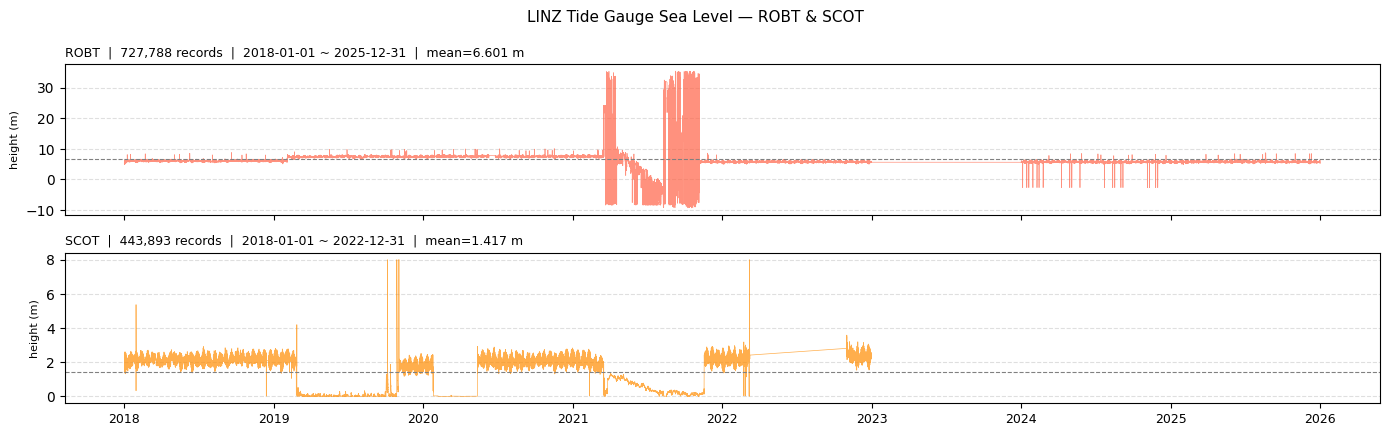

Figure saved -> /media/pzhang27/Extreme SSD/Freeboard_input_data/TideGauge/linz_tide_gauge_timeseries.png


In [34]:
all_tide_stations = list(tide_data.keys())
n_tide = len(all_tide_stations)
if n_tide == 0:
    print('No tide gauge data loaded yet. Run C21b (IOC) and C22 (LINZ) first.')
else:
    fig, axes = plt.subplots(n_tide, 1, figsize=(14, n_tide * 2.2), sharex=True)
    if n_tide == 1:
        axes = [axes]

    station_colors = {'ROBT': 'tomato', 'SCOT': 'darkorange'}

    for ax, station in zip(axes, all_tide_stations):
        df_st = tide_data[station]
        # Support both 'time' (LINZ) and 'date' (PSMSL legacy) column names
        tcol = 'time' if 'time' in df_st.columns else 'date'
        color = station_colors.get(station, 'steelblue')

        valid = df_st['height_m'].notna()
        ax.plot(df_st.loc[valid, tcol], df_st.loc[valid, 'height_m'],
                color=color, linewidth=0.5, alpha=0.7)

        ax.set_ylabel('height (m)', fontsize=8)
        ax.set_title(f'{station}  |  {valid.sum():,} records  |  '
                     f'{df_st[tcol].min().date()} ~ {df_st[tcol].max().date()}  |  '
                     f'mean={df_st.loc[valid, "height_m"].mean():.3f} m',
                     fontsize=9, loc='left')
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.axhline(df_st.loc[valid, 'height_m'].mean(), color='grey',
                   linewidth=0.8, linestyle='--')

    axes[-1].xaxis.set_major_locator(mdates.YearLocator(1))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, fontsize=9)

    fig.suptitle('LINZ Tide Gauge Sea Level — ROBT & SCOT', fontsize=11)
    plt.tight_layout()
    out_fig = os.path.join(TIDE_DIR, 'linz_tide_gauge_timeseries.png')
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved -> {out_fig}')


## C4. ROBT Tide Gauge — Data Masking, Jump Calibration & Outlier Removal


ROBT_00_2018.csv: 105120 records
ROBT_00_2019.csv: 105120 records
ROBT_00_2020.csv: 100795 records
ROBT_00_2021.csv: 102386 records
ROBT_00_2022.csv: 104458 records
ROBT_00_2023.csv: 95024 records
ROBT_00_2024.csv: 105349 records
ROB_00_2025.csv: 105120 records

Total records: 821294
Date range: 2018-01-01 00:00:00 → 2030-06-12 00:30:00
Saved raw.csv  (821294 rows) -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/raw.csv
After masking: 752025 records  (removed 69269)
Saved filtered.csv (752025 rows) -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/filtered.csv


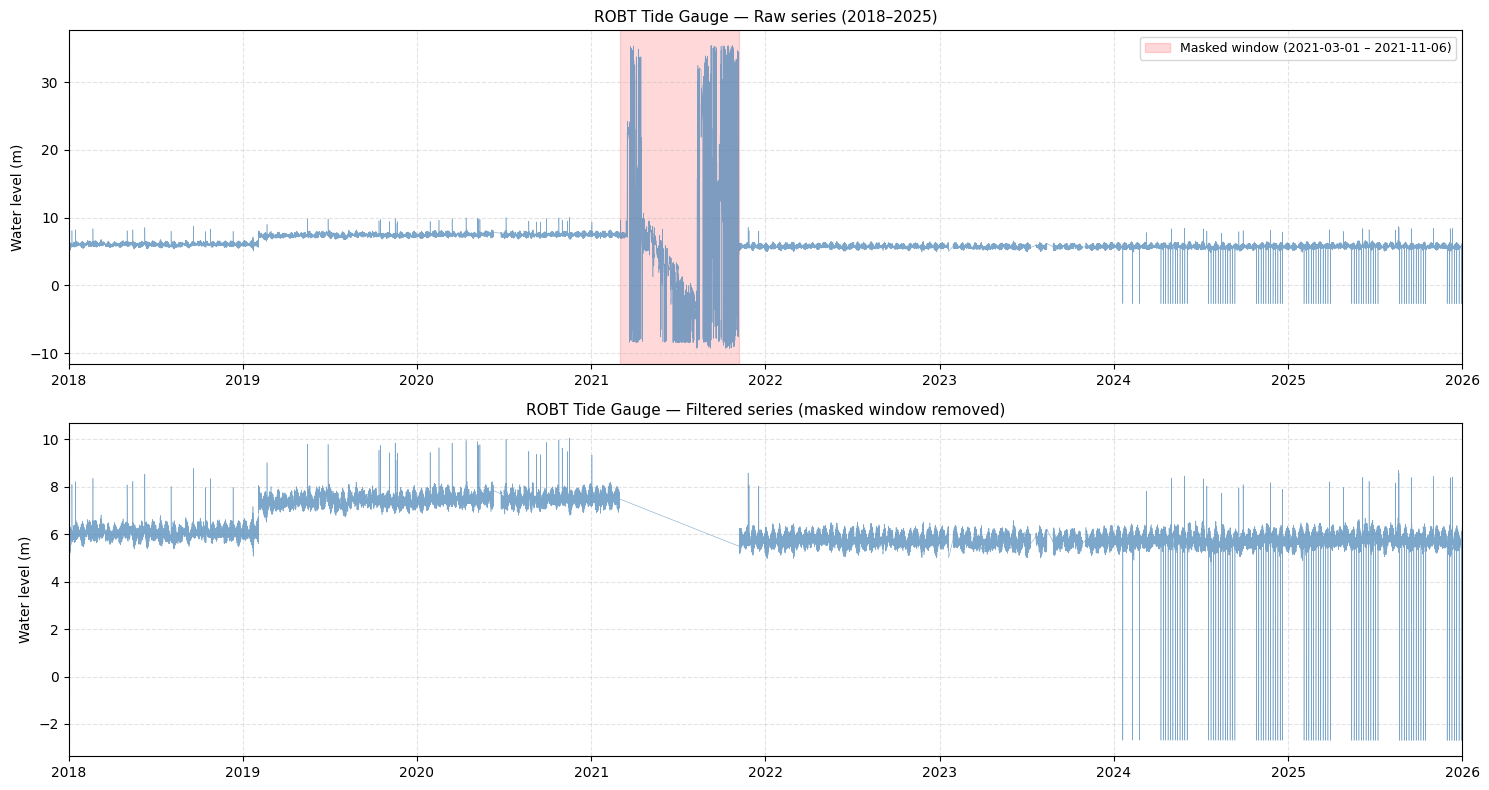

Figure 1 saved -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/C4_fig1_raw_vs_filtered.png

Jump calibration:
  Before window: 2018-12-05 – 2019-02-02  (60 days, mean = 6.0833 m)
  After  window: 2019-02-03 – 2019-04-03  (60 days, mean = 7.3266 m)
  Offset (after - before) = +1.2432 m
  Correction applied to: 2019-02-03 – 2021-02-28
Saved calibrated.csv (752025 rows) -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/calibrated.csv


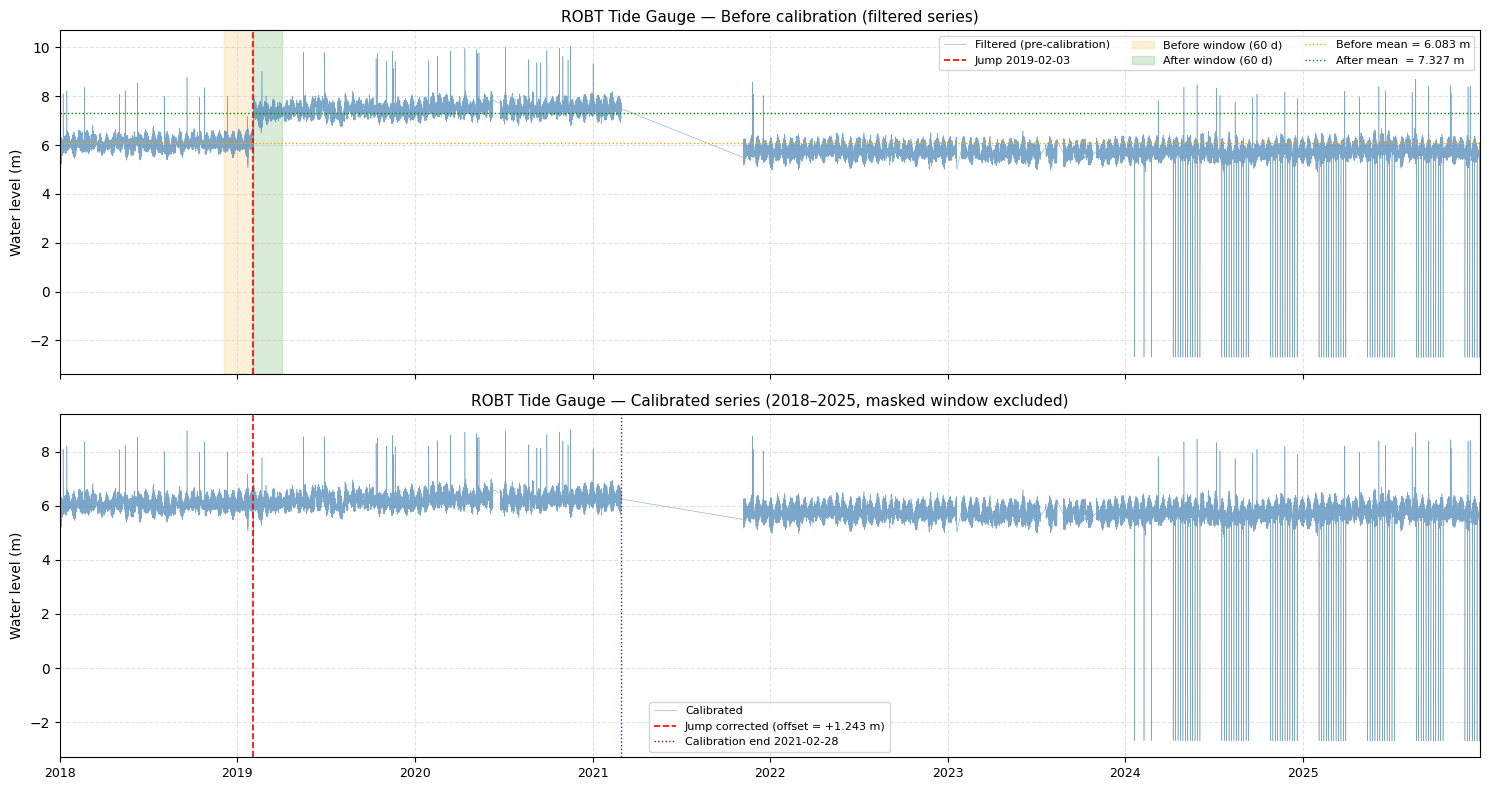

Figure 2 saved -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/C4_fig2_calibrated.png


In [35]:
# ── ROBT Tide Gauge: Masking & Jump Calibration ─────────────────────
import os
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROBT_DIR   = r"/media/pzhang27/Extreme SSD/Freeboard_input_data/TideGauge/ROBT"
OUT_DIR    = r"/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Parse LINZ ROBT CSVs (two formats) ───────────────────────────────────
def parse_robt_csv(filepath):
    """Return list of (datetime, height_m) from one ROBT LINZ CSV."""
    rows = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            try:
                # Format A: year,doy,HHMM,interval,height,...
                if parts[0].isdigit() and len(parts[0]) == 4:
                    year  = int(parts[0])
                    doy   = int(parts[1])
                    hhmm  = int(parts[2])
                    h     = float(parts[4])
                    if abs(h) > 100:          # fill value (e.g. 6999)
                        continue
                    hh, mm = divmod(hhmm, 100)
                    dt = (datetime.datetime(year, 1, 1)
                          + datetime.timedelta(days=doy - 1,
                                               hours=hh, minutes=mm))
                # Format B: ROBT,YYYYMMDD,HH:MM:SS,height,interval,...
                else:
                    date_str = parts[1]       # '20230101'
                    time_str = parts[2]       # '0:00:00'
                    h        = float(parts[3])
                    if abs(h) > 100:
                        continue
                    dt = datetime.datetime.strptime(
                             date_str + ' ' + time_str, '%Y%m%d %H:%M:%S')
                rows.append((dt, h))
            except (ValueError, IndexError):
                continue
    return rows


# ── Load all years 2018-2025 ──────────────────────────────────────────────
all_rows = []
csv_map = {
    2018: 'ROBT_00_2018.csv', 2019: 'ROBT_00_2019.csv',
    2020: 'ROBT_00_2020.csv', 2021: 'ROBT_00_2021.csv',
    2022: 'ROBT_00_2022.csv', 2023: 'ROBT_00_2023.csv',
    2024: 'ROBT_00_2024.csv', 2025: 'ROB_00_2025.csv',
}
for yr in sorted(csv_map):
    fpath = os.path.join(ROBT_DIR, csv_map[yr])
    if not os.path.exists(fpath):
        print(f'[SKIP] {csv_map[yr]} not found')
        continue
    rows = parse_robt_csv(fpath)
    all_rows.extend(rows)
    print(f'{csv_map[yr]}: {len(rows)} records')

# Sort and deduplicate
all_rows.sort(key=lambda x: x[0])
seen, unique = set(), []
for dt, h in all_rows:
    if dt not in seen:
        seen.add(dt)
        unique.append((dt, h))
all_rows = unique

times_raw = [r[0] for r in all_rows]
h_raw     = [r[1] for r in all_rows]
print(f'\nTotal records: {len(all_rows)}')
print(f'Date range: {times_raw[0]} → {times_raw[-1]}')


# ── Save raw.csv ──────────────────────────────────────────────────────────
raw_csv = os.path.join(OUT_DIR, 'raw.csv')
with open(raw_csv, 'w') as fh:
    fh.write('time,height_m\n')
    for dt, h in zip(times_raw, h_raw):
        fh.write(f'{dt.strftime("%Y-%m-%d %H:%M:%S")},{h:.4f}\n')
print(f'Saved raw.csv  ({len(times_raw)} rows) -> {raw_csv}')


# ── Mask window: 2021-03-01 to 2021-11-06 (inclusive) ────────────────────
MASK_START = datetime.datetime(2021,  3,  1)
MASK_END   = datetime.datetime(2021, 11,  6, 23, 59, 59)

times_filt = [dt for dt in times_raw
              if not (MASK_START <= dt <= MASK_END)]
h_filt     = [h  for dt, h in zip(times_raw, h_raw)
              if not (MASK_START <= dt <= MASK_END)]
print(f'After masking: {len(times_filt)} records  '
      f'(removed {len(times_raw) - len(times_filt)})')

# Save filtered.csv
filt_csv = os.path.join(OUT_DIR, 'filtered.csv')
with open(filt_csv, 'w') as fh:
    fh.write('time,height_m\n')
    for dt, h in zip(times_filt, h_filt):
        fh.write(f'{dt.strftime("%Y-%m-%d %H:%M:%S")},{h:.4f}\n')
print(f'Saved filtered.csv ({len(times_filt)} rows) -> {filt_csv}')


# ── Figure 1: raw vs filtered ─────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 1, figsize=(15, 8), sharex=False)

# Top: raw
axes1[0].plot(times_raw, h_raw, lw=0.4, color='steelblue', alpha=0.7)
axes1[0].axvspan(MASK_START, MASK_END, color='red', alpha=0.15,
                 label='Masked window (2021-03-01 – 2021-11-06)')
axes1[0].set_ylabel('Water level (m)', fontsize=10)
axes1[0].set_title('ROBT Tide Gauge — Raw series (2018–2025)', fontsize=11)
axes1[0].legend(fontsize=9)
axes1[0].grid(linestyle='--', alpha=0.35)
axes1[0].xaxis.set_major_locator(mdates.YearLocator())
axes1[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Bottom: filtered
axes1[1].plot(times_filt, h_filt, lw=0.4, color='steelblue', alpha=0.7)
axes1[1].set_ylabel('Water level (m)', fontsize=10)
axes1[1].set_title('ROBT Tide Gauge — Filtered series (masked window removed)',
                   fontsize=11)
axes1[1].grid(linestyle='--', alpha=0.35)
axes1[1].xaxis.set_major_locator(mdates.YearLocator())
axes1[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes1:
    ax.set_xlim(datetime.datetime(2018, 1, 1), datetime.datetime(2026, 1, 1))

plt.tight_layout()
out_fig1 = os.path.join(OUT_DIR, 'C4_fig1_raw_vs_filtered.png')
plt.savefig(out_fig1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure 1 saved -> {out_fig1}')


# ── Jump calibration ──────────────────────────────────────────────────────
JUMP_DATE  = datetime.datetime(2019, 2, 3)
CAL_END    = datetime.datetime(2021, 2, 28, 23, 59, 59)

BEFORE_START = JUMP_DATE - datetime.timedelta(days=60)   # 2018-12-05
BEFORE_END   = JUMP_DATE - datetime.timedelta(seconds=1) # 2019-02-02 23:59:59
AFTER_START  = JUMP_DATE                                  # 2019-02-03
AFTER_END    = JUMP_DATE + datetime.timedelta(days=60) - datetime.timedelta(seconds=1)

# Daily means helper
def daily_means(times, heights, start, end):
    """Return dict {date: mean_height} for the given window."""
    day_sums = {}
    for dt, h in zip(times, heights):
        if start <= dt <= end:
            d = dt.date()
            if d not in day_sums:
                day_sums[d] = []
            day_sums[d].append(h)
    return {d: np.mean(v) for d, v in day_sums.items()}

before_daily = daily_means(times_raw, h_raw, BEFORE_START, BEFORE_END)
after_daily  = daily_means(times_raw, h_raw, AFTER_START,  AFTER_END)

mean_before = np.mean(list(before_daily.values()))
mean_after  = np.mean(list(after_daily.values()))
offset      = mean_after - mean_before

print(f'\nJump calibration:')
print(f'  Before window: {BEFORE_START.date()} – {BEFORE_END.date()}  '
      f'({len(before_daily)} days, mean = {mean_before:.4f} m)')
print(f'  After  window: {AFTER_START.date()} – {AFTER_END.date()}  '
      f'({len(after_daily)} days, mean = {mean_after:.4f} m)')
print(f'  Offset (after - before) = {offset:+.4f} m')
print(f'  Correction applied to: {JUMP_DATE.date()} – {CAL_END.date()}')

# Apply calibration to filtered series
h_cal = []
for dt, h in zip(times_filt, h_filt):
    if JUMP_DATE <= dt <= CAL_END:
        h_cal.append(h - offset)
    else:
        h_cal.append(h)

# Save calibrated.csv
cal_csv = os.path.join(OUT_DIR, 'calibrated.csv')
with open(cal_csv, 'w') as fh:
    fh.write('time,height_m\n')
    for dt, h in zip(times_filt, h_cal):
        fh.write(f'{dt.strftime("%Y-%m-%d %H:%M:%S")},{h:.4f}\n')
print(f'Saved calibrated.csv ({len(times_filt)} rows) -> {cal_csv}')


# ── Figure 2: before/after calibration + offset annotation ───────────────
fig2, axes2 = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Top: filtered (pre-calibration)
axes2[0].plot(times_filt, h_filt, lw=0.4, color='steelblue', alpha=0.7,
              label='Filtered (pre-calibration)')
axes2[0].axvline(JUMP_DATE, color='red', lw=1.2, ls='--', label='Jump 2019-02-03')
axes2[0].axvspan(BEFORE_START, BEFORE_END, color='orange', alpha=0.15,
                 label='Before window (60 d)')
axes2[0].axvspan(AFTER_START, AFTER_END, color='green', alpha=0.15,
                 label='After window (60 d)')
axes2[0].axhline(mean_before, color='orange', lw=1.0, ls=':',
                 label=f'Before mean = {mean_before:.3f} m')
axes2[0].axhline(mean_after,  color='green',  lw=1.0, ls=':',
                 label=f'After mean  = {mean_after:.3f} m')
axes2[0].set_ylabel('Water level (m)', fontsize=10)
axes2[0].set_title('ROBT Tide Gauge — Before calibration (filtered series)',
                   fontsize=11)
axes2[0].legend(fontsize=8, ncol=3)
axes2[0].grid(linestyle='--', alpha=0.35)

# Bottom: calibrated
axes2[1].plot(times_filt, h_cal, lw=0.4, color='steelblue', alpha=0.7,
              label='Calibrated')
axes2[1].axvline(JUMP_DATE, color='red', lw=1.2, ls='--',
                 label=f'Jump corrected (offset = {offset:+.3f} m)')
axes2[1].axvline(CAL_END,   color='purple', lw=1.0, ls=':',
                 label=f'Calibration end {CAL_END.date()}')
axes2[1].set_ylabel('Water level (m)', fontsize=10)
axes2[1].set_title('ROBT Tide Gauge — Calibrated series (2018–2025, masked window excluded)',
                   fontsize=11)
axes2[1].legend(fontsize=8)
axes2[1].grid(linestyle='--', alpha=0.35)

for ax in axes2:
    ax.set_xlim(datetime.datetime(2018, 1, 1), datetime.datetime(2025, 12, 31))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
out_fig2 = os.path.join(OUT_DIR, 'C4_fig2_calibrated.png')
plt.savefig(out_fig2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure 2 saved -> {out_fig2}')


Loaded 752025 records from calibrated.csv
Outliers removed : 149  (0.02 %)
Records kept     : 751876
Saved -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/outliers_removed.csv


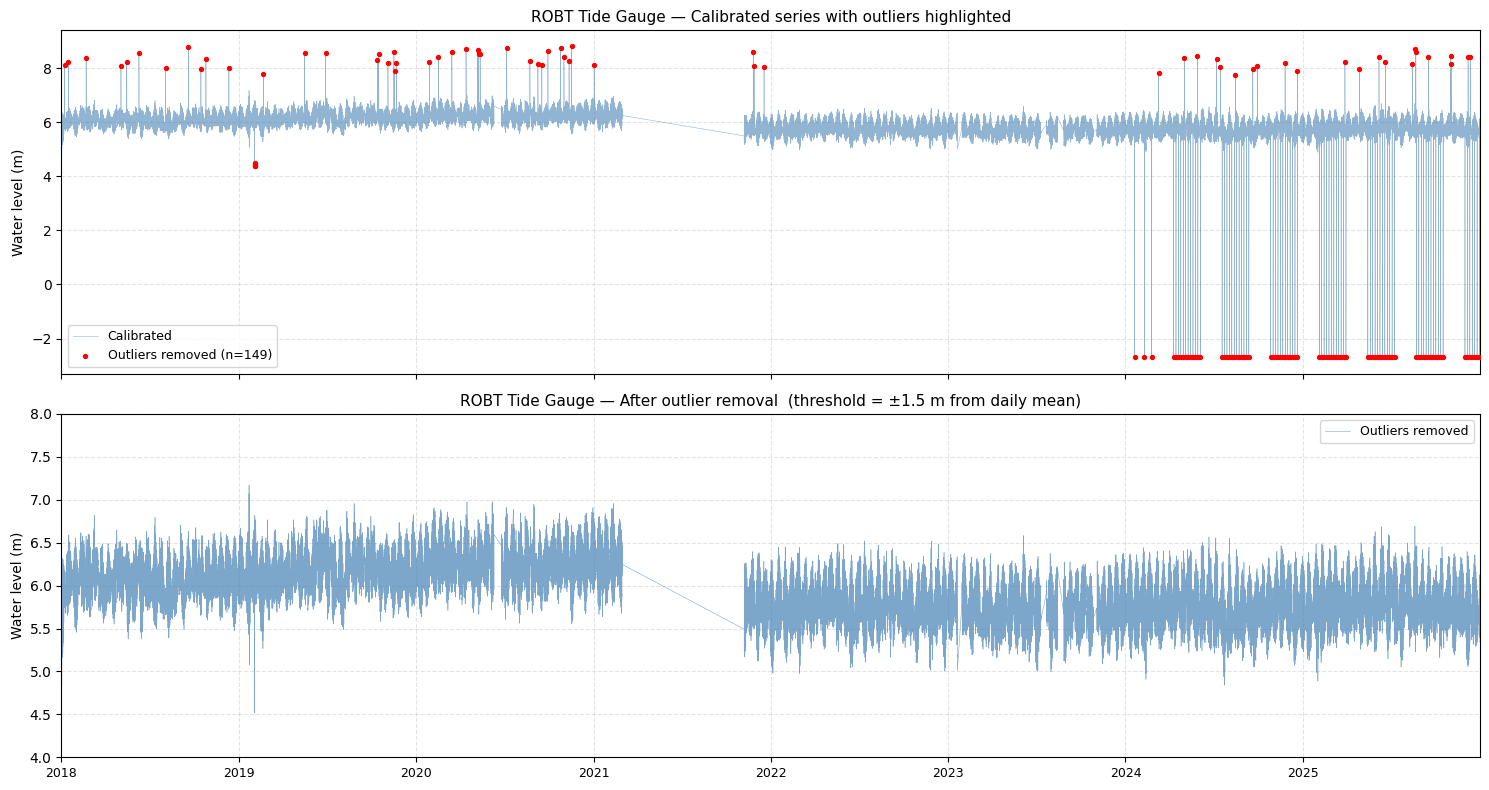

Figure saved -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/C5_outliers_removed.png


In [36]:
# ── ROBT Tide Gauge: Outlier Removal ────────────────────────────────
import os
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TG_DIR   = r"/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt"
IN_CSV   = os.path.join(TG_DIR, "calibrated.csv")
OUT_CSV  = os.path.join(TG_DIR, "outliers_removed.csv")
THRESHOLD = 1.5   # metres

# ── Load calibrated.csv ───────────────────────────────────────────────────
times, heights = [], []
with open(IN_CSV) as fh:
    next(fh)                          # skip header
    for line in fh:
        line = line.strip()
        if not line:
            continue
        t_str, h_str = line.split(',')
        times.append(datetime.datetime.strptime(t_str, '%Y-%m-%d %H:%M:%S'))
        heights.append(float(h_str))

print(f"Loaded {len(times)} records from calibrated.csv")

# ── Compute daily means ───────────────────────────────────────────────────
day_vals = {}
for dt, h in zip(times, heights):
    d = dt.date()
    if d not in day_vals:
        day_vals[d] = []
    day_vals[d].append(h)

daily_mean = {d: np.mean(v) for d, v in day_vals.items()}

# ── Flag outliers ─────────────────────────────────────────────────────────
keep_mask = []
for dt, h in zip(times, heights):
    dm = daily_mean[dt.date()]
    keep_mask.append(abs(h - dm) <= THRESHOLD)

times_clean  = [t for t, k in zip(times,   keep_mask) if k]
heights_clean = [h for h, k in zip(heights, keep_mask) if k]
times_out    = [t for t, k in zip(times,   keep_mask) if not k]
heights_out  = [h for h, k in zip(heights, keep_mask) if not k]

n_removed = len(times) - len(times_clean)
print(f"Outliers removed : {n_removed}  ({100*n_removed/len(times):.2f} %)")
print(f"Records kept     : {len(times_clean)}")

# ── Save outliers_removed.csv ─────────────────────────────────────────────
with open(OUT_CSV, 'w') as fh:
    fh.write('time,height_m\n')
    for dt, h in zip(times_clean, heights_clean):
        fh.write(f'{dt.strftime("%Y-%m-%d %H:%M:%S")},{h:.4f}\n')
print(f"Saved -> {OUT_CSV}")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Top: calibrated with outliers highlighted
axes[0].plot(times, heights, lw=0.4, color='steelblue', alpha=0.6,
             label='Calibrated')
if times_out:
    axes[0].scatter(times_out, heights_out, s=8, color='red', zorder=3,
                    label=f'Outliers removed (n={n_removed})')
axes[0].set_ylabel('Water level (m)', fontsize=10)
axes[0].set_title('ROBT Tide Gauge — Calibrated series with outliers highlighted',
                  fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(linestyle='--', alpha=0.35)

# Bottom: cleaned series
axes[1].plot(times_clean, heights_clean, lw=0.4, color='steelblue', alpha=0.7,
             label='Outliers removed')
axes[1].set_ylabel('Water level (m)', fontsize=10)
axes[1].set_title(
    f'ROBT Tide Gauge — After outlier removal  '
    f'(threshold = ±{THRESHOLD} m from daily mean)',
    fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(linestyle='--', alpha=0.35)
axes[1].set_ylim(4, 8)

for ax in axes:
    ax.set_xlim(datetime.datetime(2018, 1, 1), datetime.datetime(2025, 12, 31))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
out_fig = os.path.join(TG_DIR, 'C5_outliers_removed.png')
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved -> {out_fig}")


## C5. SCOT Tide Gauge — Data Masking & Outlier Removal


SCOT_00_2018.csv: 99730 records
SCOT_00_2019.csv: 100129 records
SCOT_00_2020.csv: 103738 records
SCOT_00_2021.csv: 103373 records
SCOT_00_2022.csv: 37167 records
SCOT_00_2023.csv: 0 records
SCOT_00_2024.csv: 0 records
SCOT_00_2025.csv: 0 records

Total records: 443893
Date range: 2018-01-01 00:00:00 -> 2022-12-31 23:55:00
Saved raw.csv (443893 rows) -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot/raw.csv
After masking: 276097 records (removed 167796)
Saved filtered.csv (276097 rows) -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot/filtered.csv


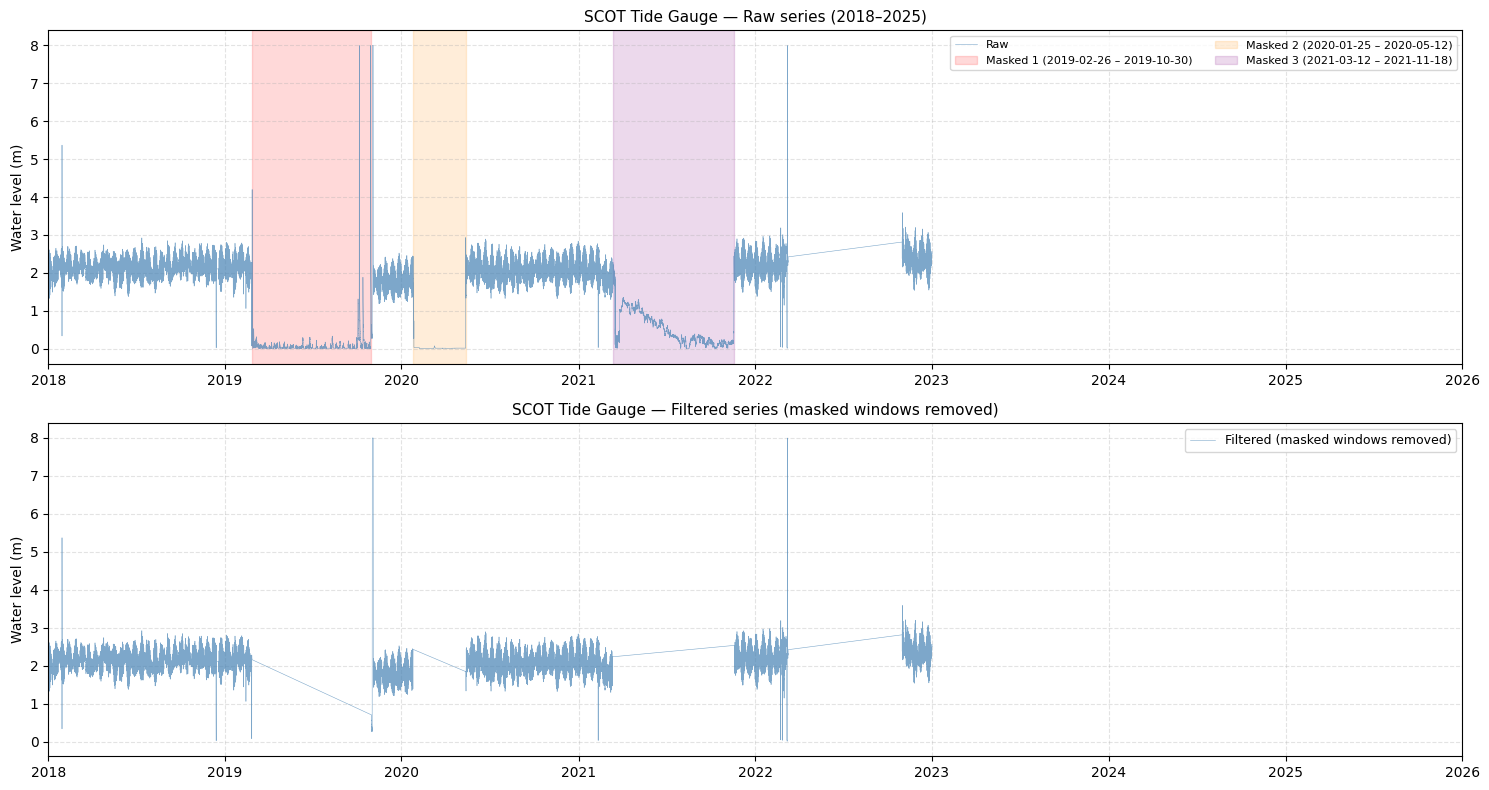

Figure saved -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot/C4b_fig_raw_vs_filtered.png


In [37]:
# ── SCOT Tide Gauge: Data Masking ──────────────────────────────────
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

SCOT_DIR = r"/media/pzhang27/Extreme SSD/Freeboard_input_data/TideGauge/SCOT"
OUT_DIR  = r"/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Parse SCOT CSVs: SCOT,YYYYMMDD,HH:MM:SS,height_m ─────────────────────
def parse_scot_csv(filepath):
    rows = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            try:
                date_str = parts[1]          # '20180101'
                time_str = parts[2]          # '0:00:00' or '00:00:00'
                h        = float(parts[3])
                if abs(h) > 100:             # fill value guard
                    continue
                dt = datetime.datetime.strptime(
                    date_str + ' ' + time_str, '%Y%m%d %H:%M:%S')
                rows.append((dt, h))
            except (ValueError, IndexError):
                continue
    return rows

# ── Load all years 2018-2025 ──────────────────────────────────────────────
all_rows = []
for yr in range(2018, 2026):
    fname = f"SCOT_00_{yr}.csv"
    fpath = os.path.join(SCOT_DIR, fname)
    if not os.path.exists(fpath):
        print(f'[SKIP] {fname} not found')
        continue
    rows = parse_scot_csv(fpath)
    all_rows.extend(rows)
    print(f'{fname}: {len(rows)} records')

# Sort and deduplicate
all_rows.sort(key=lambda x: x[0])
seen, unique = set(), []
for dt, h in all_rows:
    if dt not in seen:
        seen.add(dt)
        unique.append((dt, h))
all_rows = unique

times_raw = [r[0] for r in all_rows]
h_raw     = [r[1] for r in all_rows]
print(f'\nTotal records: {len(all_rows)}')
print(f'Date range: {times_raw[0]} -> {times_raw[-1]}')

# ── Save raw.csv ──────────────────────────────────────────────────────────
raw_csv = os.path.join(OUT_DIR, 'raw.csv')
with open(raw_csv, 'w') as fh:
    fh.write('time,height_m\n')
    for dt, h in zip(times_raw, h_raw):
        fh.write(f'{dt.strftime("%Y-%m-%d %H:%M:%S")},{h:.4f}\n')
print(f'Saved raw.csv ({len(times_raw)} rows) -> {raw_csv}')

# ── Three mask windows ────────────────────────────────────────────────────
MASKS = [
    (datetime.datetime(2019,  2, 26), datetime.datetime(2019, 10, 30, 23, 59, 59)),
    (datetime.datetime(2020,  1, 25), datetime.datetime(2020,  5, 12, 23, 59, 59)),
    (datetime.datetime(2021,  3, 12), datetime.datetime(2021, 11, 18, 23, 59, 59)),
]

def is_masked(dt):
    return any(s <= dt <= e for s, e in MASKS)

times_filt = [dt for dt in times_raw if not is_masked(dt)]
h_filt     = [h  for dt, h in zip(times_raw, h_raw) if not is_masked(dt)]
n_removed  = len(times_raw) - len(times_filt)
print(f'After masking: {len(times_filt)} records (removed {n_removed})')

# ── Save filtered.csv ─────────────────────────────────────────────────────
filt_csv = os.path.join(OUT_DIR, 'filtered.csv')
with open(filt_csv, 'w') as fh:
    fh.write('time,height_m\n')
    for dt, h in zip(times_filt, h_filt):
        fh.write(f'{dt.strftime("%Y-%m-%d %H:%M:%S")},{h:.4f}\n')
print(f'Saved filtered.csv ({len(times_filt)} rows) -> {filt_csv}')

# ── Plot ──────────────────────────────────────────────────────────────────
MASK_COLORS = ['red', 'darkorange', 'purple']
MASK_LABELS = [
    'Masked 1 (2019-02-26 – 2019-10-30)',
    'Masked 2 (2020-01-25 – 2020-05-12)',
    'Masked 3 (2021-03-12 – 2021-11-18)',
]

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)

# Top: raw with masked windows highlighted
axes[0].plot(times_raw, h_raw, lw=0.4, color='steelblue', alpha=0.7,
             label='Raw')
for (s, e), col, lbl in zip(MASKS, MASK_COLORS, MASK_LABELS):
    axes[0].axvspan(s, e, color=col, alpha=0.15, label=lbl)
axes[0].set_ylabel('Water level (m)', fontsize=10)
axes[0].set_title('SCOT Tide Gauge — Raw series (2018–2025)', fontsize=11)
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(linestyle='--', alpha=0.35)
axes[0].set_xlim(datetime.datetime(2018, 1, 1), datetime.datetime(2026, 1, 1))
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Bottom: filtered
axes[1].plot(times_filt, h_filt, lw=0.4, color='steelblue', alpha=0.7,
             label='Filtered (masked windows removed)')
axes[1].set_ylabel('Water level (m)', fontsize=10)
axes[1].set_title('SCOT Tide Gauge — Filtered series (masked windows removed)',
                  fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(linestyle='--', alpha=0.35)
axes[1].set_xlim(datetime.datetime(2018, 1, 1), datetime.datetime(2026, 1, 1))
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
out_fig = os.path.join(OUT_DIR, 'C4b_fig_raw_vs_filtered.png')
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {out_fig}')


Loaded 276097 records from filtered.csv
Stage 1 (|h| outside [0.5, 4.0] m): removed 1675 points
Stage 2 (dev > 2.0 m from daily mean): removed 0 points
Total removed: 1675  (0.61 %)
Records kept : 274422
Saved -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot/outliers_removed.csv


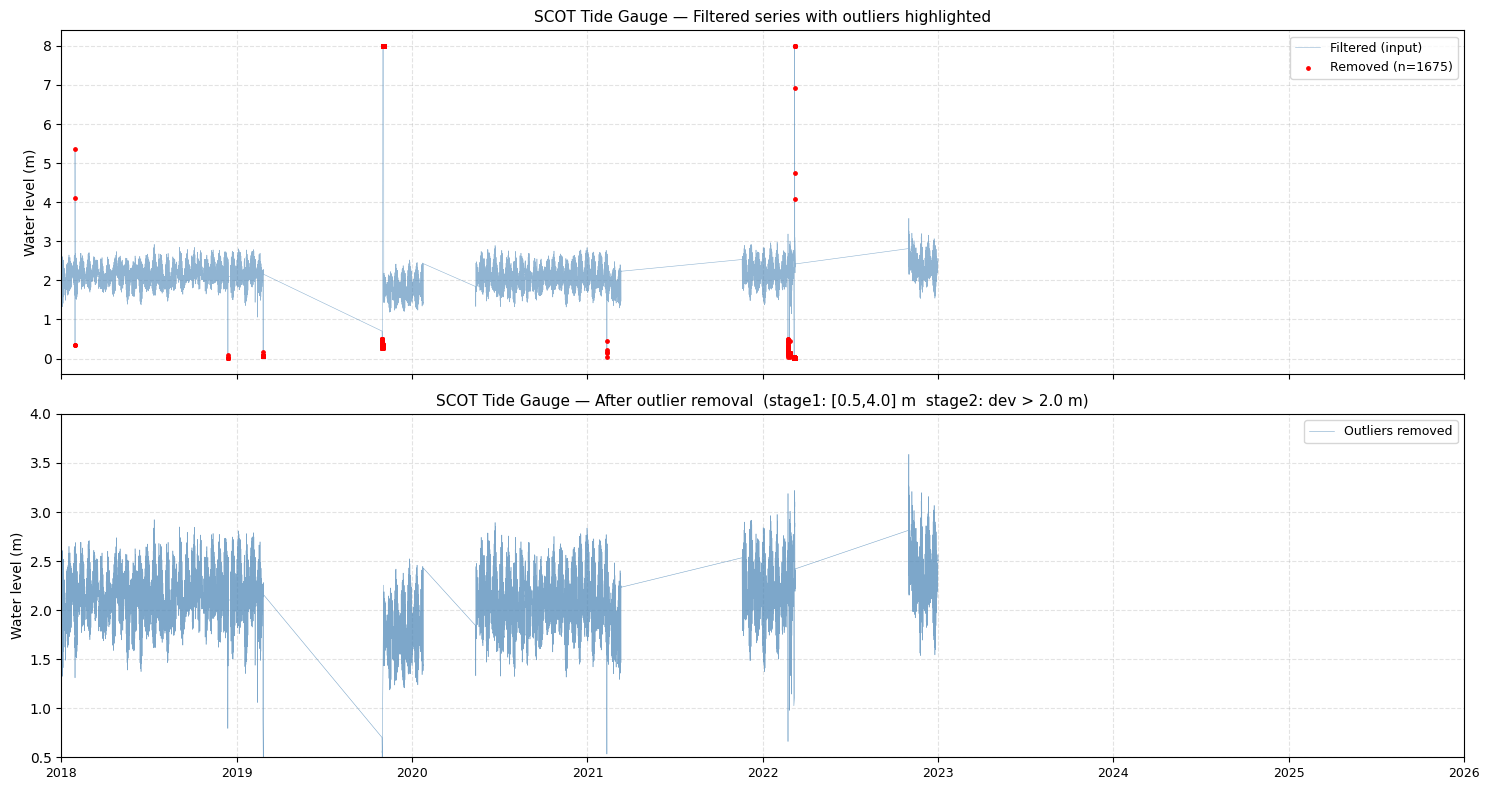

Figure saved -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot/C4c_outliers_removed.png


In [38]:
# ── SCOT Tide Gauge: Outlier Removal ────────────────────────────────
import os
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TG_DIR    = r"/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot"
IN_CSV    = os.path.join(TG_DIR, "filtered.csv")
OUT_CSV   = os.path.join(TG_DIR, "outliers_removed.csv")

# Two-stage filter:
#   Stage 1 — absolute range: removes sensor saturation values (0.011, 7.999)
#   Stage 2 — daily-mean deviation: removes remaining short spikes
H_MIN      = 0.5    # metres  (below this = sensor lower-limit fill value)
H_MAX      = 4.0    # metres  (above this = sensor upper-limit fill value)
DEV_THRESH = 2.0    # metres  deviation from daily mean

# ── Load filtered.csv ─────────────────────────────────────────────────────
times, heights = [], []
with open(IN_CSV) as fh:
    next(fh)
    for line in fh:
        line = line.strip()
        if not line:
            continue
        t_str, h_str = line.split(',')
        times.append(datetime.datetime.strptime(t_str, '%Y-%m-%d %H:%M:%S'))
        heights.append(float(h_str))

print(f"Loaded {len(times)} records from filtered.csv")

# ── Stage 1: absolute range filter ───────────────────────────────────────
mask_s1 = [H_MIN <= h <= H_MAX for h in heights]
times_s1   = [t for t, k in zip(times,   mask_s1) if k]
heights_s1 = [h for h, k in zip(heights, mask_s1) if k]
n_s1 = len(times) - len(times_s1)
print(f"Stage 1 (|h| outside [{H_MIN}, {H_MAX}] m): removed {n_s1} points")

# ── Stage 2: daily-mean deviation filter ─────────────────────────────────
day_vals = {}
for dt, h in zip(times_s1, heights_s1):
    d = dt.date()
    if d not in day_vals:
        day_vals[d] = []
    day_vals[d].append(h)

daily_mean = {d: np.mean(v) for d, v in day_vals.items()}

mask_s2 = [abs(h - daily_mean[dt.date()]) <= DEV_THRESH
           for dt, h in zip(times_s1, heights_s1)]
times_clean   = [t for t, k in zip(times_s1,   mask_s2) if k]
heights_clean = [h for h, k in zip(heights_s1, mask_s2) if k]
times_out2    = [t for t, k in zip(times_s1,   mask_s2) if not k]
heights_out2  = [h for h, k in zip(heights_s1, mask_s2) if not k]
n_s2 = len(times_s1) - len(times_clean)
print(f"Stage 2 (dev > {DEV_THRESH} m from daily mean): removed {n_s2} points")

n_total = len(times) - len(times_clean)
print(f"Total removed: {n_total}  ({100*n_total/len(times):.2f} %)")
print(f"Records kept : {len(times_clean)}")

# ── Save outliers_removed.csv ─────────────────────────────────────────────
with open(OUT_CSV, 'w') as fh:
    fh.write('time,height_m\n')
    for dt, h in zip(times_clean, heights_clean):
        fh.write(f'{dt.strftime("%Y-%m-%d %H:%M:%S")},{h:.4f}\n')
print(f"Saved -> {OUT_CSV}")

# ── Collect all removed points for plotting ───────────────────────────────
times_removed  = [t for t, k in zip(times, mask_s1) if not k] + times_out2
heights_removed = [h for h, k in zip(heights, mask_s1) if not k] + heights_out2

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Top: filtered with all removed points highlighted
axes[0].plot(times, heights, lw=0.4, color='steelblue', alpha=0.6,
             label='Filtered (input)')
if times_removed:
    axes[0].scatter(times_removed, heights_removed, s=6, color='red',
                    zorder=3, label=f'Removed (n={len(times_removed)})')
axes[0].set_ylabel('Water level (m)', fontsize=10)
axes[0].set_title('SCOT Tide Gauge — Filtered series with outliers highlighted',
                  fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(linestyle='--', alpha=0.35)

# Bottom: cleaned series (y-axis limited to meaningful range)
axes[1].plot(times_clean, heights_clean, lw=0.4, color='steelblue', alpha=0.7,
             label='Outliers removed')
axes[1].set_ylabel('Water level (m)', fontsize=10)
axes[1].set_title(
    f'SCOT Tide Gauge — After outlier removal  '
    f'(stage1: [{H_MIN},{H_MAX}] m  stage2: dev > {DEV_THRESH} m)',
    fontsize=11)
axes[1].set_ylim(H_MIN, H_MAX)
axes[1].legend(fontsize=9)
axes[1].grid(linestyle='--', alpha=0.35)

for ax in axes:
    ax.set_xlim(datetime.datetime(2018, 1, 1), datetime.datetime(2026, 1, 1))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
out_fig = os.path.join(TG_DIR, 'C4c_outliers_removed.png')
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved -> {out_fig}")


## D. Datum Conversion — Tide Gauge to Ellipsoid Height

Tide gauge data is recorded relative to a local benchmark / Chart Datum.
To compare with ICESat-2 ellipsoidal heights (WGS84), we must shift each
tide gauge record by a known offset.

| Station | Instrument | Datum offset to ellipsoid (m) | Notes |
|---------|-----------|-------------------------------|-------|
| ROBT    | LINZ | benchmark B93M | -54.586 m |
| SCOT    | LINZ | benchmark DJRB | -44.748 m |


### D1. Datum offset configuration


In [39]:
# ── D1. Ellipsoid datum offsets ────────────────────────────────────────────
# Each value is the offset to ADD to the tide gauge reading (in metres)
# to obtain height above WGS84 ellipsoid:
#   h_ellipsoid = h_gauge + datum_offset

DATUM_OFFSET = {
    'ROBT': -54.586,   # benchmark B93M
    'SCOT': -44.748,   # benchmark DJRB
}

print('Datum offsets (tide gauge -> WGS84 ellipsoid):')
for name, offset in DATUM_OFFSET.items():
    print(f'  {name:<6}  {offset:+.4f} m')


Datum offsets (tide gauge -> WGS84 ellipsoid):
  ROBT    -54.5860 m
  SCOT    -44.7480 m


### D2. Convert ROBT & SCOT tide gauge to ellipsoid height

**Formula:**
```
TGZ_ellipsoid(t) = benchmark_ellipsoid - TGZ_below_benchmark(t)
h_ellipsoid(t)   = h_gauge(t) + TGZ_ellipsoid(t)
```
where `TGZ_below_benchmark(t)` is linearly interpolated from annual November levelling surveys.


In [40]:
import numpy as np
import pandas as pd
import os

# ── Annual levelling surveys: TGZ below benchmark (metres) ────────────────
# Measured each November; we interpolate linearly between survey dates.
# Only 2021-2025 used (2018/2019 excluded per project scope).
LEVELLING = {
    'ROBT': {
        # benchmark B93M  ellipsoid height = -54.586 m
        'benchmark_ellipsoid': -54.586,
        'surveys': [
            # (year, month, TGZ_below_benchmark_m)
            (2018, 11, 8.215),
            (2021, 11, 7.766),
            (2022, 11, 7.726),
            (2023, 11, 7.691),
            (2024, 11, 7.768),
            (2025, 11, 7.820),
        ],
    },
    'SCOT': {
        # benchmark DJRB  ellipsoid height = -44.748 m
        'benchmark_ellipsoid': -44.748,
        'surveys': [
            (2018, 11, 11.573),
            (2019, 11, 11.232),
            (2020, 11, 11.409),
            (2021, 11, 11.533),
            (2022, 11, 11.678),
            (2023, 11, 11.698),
            (2024, 11, 11.934),
            (2025, 11, 11.067),
        ],
    },
}

# Per-station time ranges (SCOT starts 2019, ROBT starts 2021)
LINZ_RANGE = {
    'ROBT': (pd.Timestamp('2018-01-01'), pd.Timestamp('2025-12-31 23:59:59')),
    'SCOT': (pd.Timestamp('2018-01-01'), pd.Timestamp('2025-12-31 23:59:59')),
}
OUTPUT_TIDE = r'/home/pzhang27/workspace/Freeboard/output'
os.makedirs(OUTPUT_TIDE, exist_ok=True)

# ── Build interpolator for TGZ_ellipsoid(t) ───────────────────────────────
def make_tgz_interpolator(station_cfg):
    bm_ell     = station_cfg['benchmark_ellipsoid']
    surveys    = station_cfg['surveys']
    survey_ts  = np.array([pd.Timestamp(y, m, 15).value for y, m, _ in surveys], dtype=float)
    survey_tgz = np.array([bm_ell - tzb for _, _, tzb in surveys], dtype=float)
    def interpolate(timestamps):
        t_vals = np.array([ts.value for ts in timestamps], dtype=float)
        return np.interp(t_vals, survey_ts, survey_tgz,
                         left=survey_tgz[0], right=survey_tgz[-1])
    return interpolate

# ── Apply conversion and save ─────────────────────────────────────────────
tide_data_ellipsoid = {}

ROBT_CLEAN_CSV = r'/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/outliers_removed.csv'
ROBT_ELL_CSV   = r'/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/outliers_removed_ellipsoid.csv'
SCOT_CLEAN_CSV = r'/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot/outliers_removed.csv'
SCOT_ELL_CSV   = r'/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot/outliers_removed_ellipsoid.csv'

for station, cfg in LEVELLING.items():
    # ── ROBT: read from outliers_removed.csv (C5 output) ─────────────────
    if station == 'ROBT':
        if not os.path.exists(ROBT_CLEAN_CSV):
            print(f'[ROBT] outliers_removed.csv not found — run C5 first')
            continue
        df = pd.read_csv(ROBT_CLEAN_CSV, parse_dates=['time'])
    # ── SCOT: read from outliers_removed.csv (C4c output) ────────────────
    else:
        if not os.path.exists(SCOT_CLEAN_CSV):
            print(f'[SCOT] outliers_removed.csv not found — run C4c first')
            continue
        df = pd.read_csv(SCOT_CLEAN_CSV, parse_dates=['time'])

    start, end = LINZ_RANGE.get(station, (pd.Timestamp('2018-01-01'), pd.Timestamp('2025-12-31 23:59:59')))
    mask = (df['time'] >= start) & (df['time'] <= end)
    df = df[mask].reset_index(drop=True)
    if df.empty:
        print(f'[{station}] no data in range')
        continue

    interp_fn = make_tgz_interpolator(cfg)
    df['tgz_ellipsoid'] = interp_fn(df['time'])
    df['h_ellipsoid']   = df['height_m'] + df['tgz_ellipsoid']

    tide_data_ellipsoid[station] = df

    # ── Save to CSV ───────────────────────────────────────────────────────
    out_cols = ['time', 'height_m', 'tgz_ellipsoid', 'h_ellipsoid']
    if station == 'ROBT':
        out_path = ROBT_ELL_CSV
    else:
        out_path = SCOT_ELL_CSV
    df[out_cols].to_csv(out_path, index=False, float_format='%.6f')

    print(f'[{station}]  {len(df):,} records  |  '
          f'{df["time"].min().date()} ~ {df["time"].max().date()}')
    print(f'  TGZ ellipsoid : {df["tgz_ellipsoid"].min():.4f} ~ '
                             f'{df["tgz_ellipsoid"].max():.4f} m')
    print(f'  h_ellipsoid   : {df["h_ellipsoid"].min():.4f} ~ '
                             f'{df["h_ellipsoid"].max():.4f} m')
    print(f'  Saved -> {out_path}')

[ROBT]  751,679 records  |  2018-01-01 ~ 2025-12-31
  TGZ ellipsoid : -62.8010 ~ -62.2770 m
  h_ellipsoid   : -58.2504 ~ -55.5089 m
  Saved -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/outliers_removed_ellipsoid.csv
[SCOT]  274,422 records  |  2018-01-01 ~ 2022-12-31
  TGZ ellipsoid : -56.4286 ~ -55.9800 m
  h_ellipsoid   : -55.7221 ~ -52.8326 m
  Saved -> /media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot/outliers_removed_ellipsoid.csv


### D3. Plot ellipsoid-corrected sea surface height (ROBT & SCOT)


[ROBT]  751,679 records  |  2018-01-01 ~ 2025-12-31  |  h_ellipsoid: -58.250 ~ -55.509 m
[SCOT]  274,422 records  |  2018-01-01 ~ 2022-12-31  |  h_ellipsoid: -55.722 ~ -52.833 m


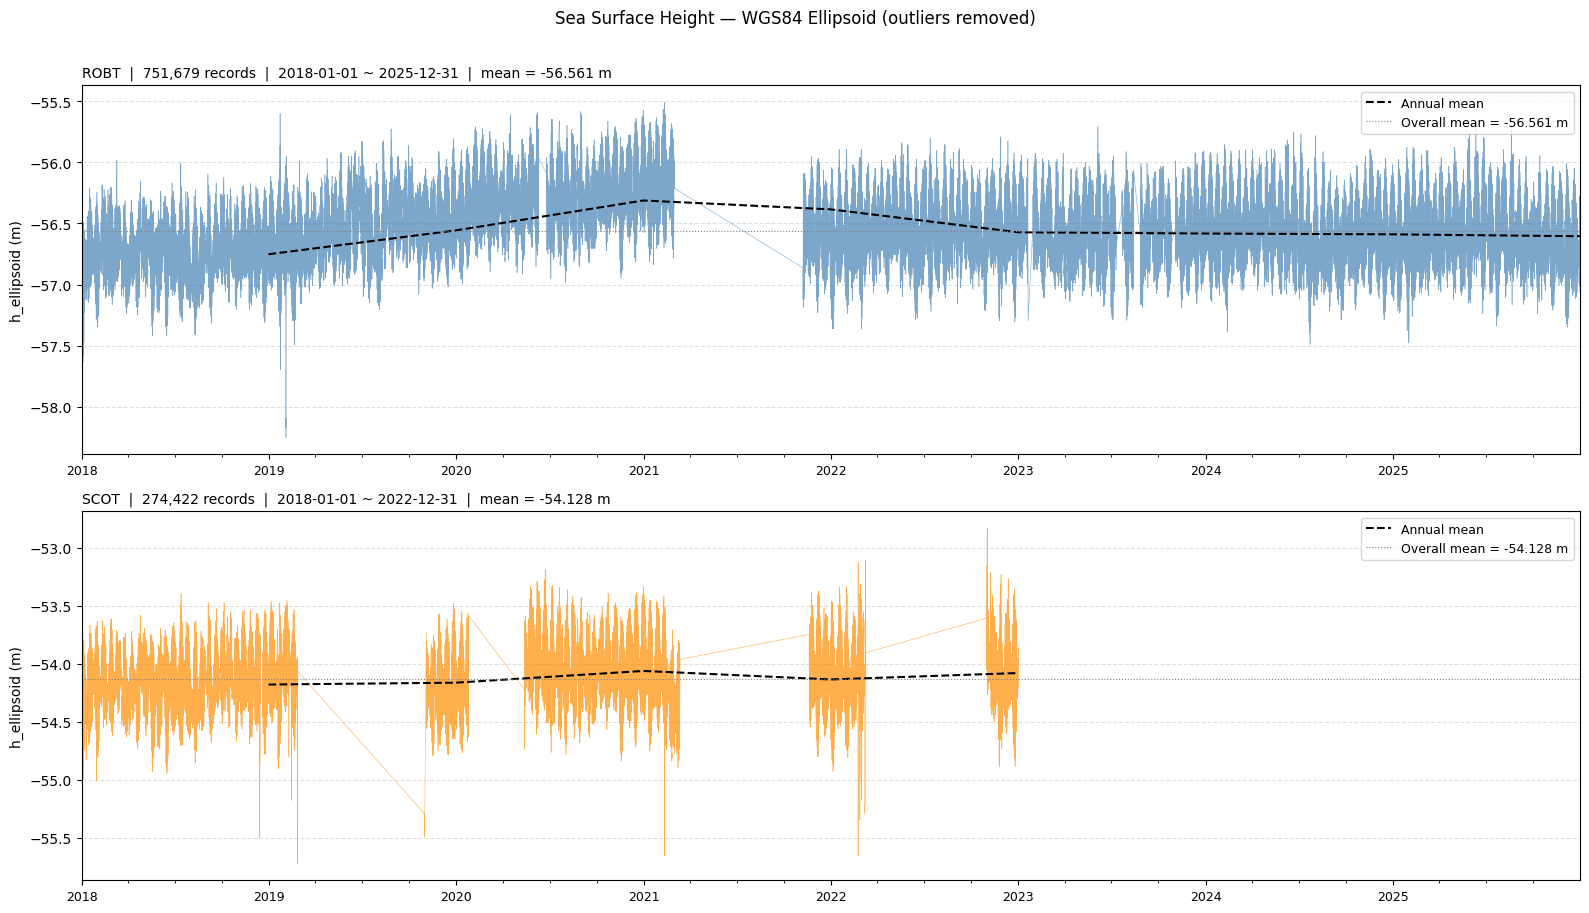

Saved -> /home/pzhang27/workspace/Freeboard/output/ROBT_SCOT_ellipsoid_height.png


In [41]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

OUTPUT_TIDE  = r'/home/pzhang27/workspace/Freeboard/output'

STATIONS = {
    'ROBT': {
        'csv'  : r'/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/outliers_removed_ellipsoid.csv',
        'color': 'steelblue',
    },
    'SCOT': {
        'csv'  : r'/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot/outliers_removed_ellipsoid.csv',
        'color': 'darkorange',
    },
}

# ── Load data ─────────────────────────────────────────────────────────────
dfs = {}
for station, cfg in STATIONS.items():
    if not os.path.exists(cfg['csv']):
        print(f'[{station}] file not found: {cfg["csv"]} — run D2 first')
        continue
    df = pd.read_csv(cfg['csv'], parse_dates=['time'])
    dfs[station] = df
    print(f'[{station}]  {len(df):,} records  |  '
          f'{df["time"].min().date()} ~ {df["time"].max().date()}  |  '
          f'h_ellipsoid: {df["h_ellipsoid"].min():.3f} ~ {df["h_ellipsoid"].max():.3f} m')

# ── Plot: one subplot per station ─────────────────────────────────────────
n = len(dfs)
if n == 0:
    print('No data to plot.')
else:
    fig, axes = plt.subplots(n, 1, figsize=(16, 4.5 * n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, (station, df) in zip(axes, dfs.items()):
        col = STATIONS[station]['color']

        ax.plot(df['time'], df['h_ellipsoid'],
                color=col, linewidth=0.4, alpha=0.7)

        # Annual mean overlay
        annual = df.set_index('time')['h_ellipsoid'].resample('YE').mean().reset_index()
        ax.plot(annual['time'], annual['h_ellipsoid'],
                color='black', linewidth=1.5, linestyle='--', label='Annual mean')

        ax.axhline(df['h_ellipsoid'].mean(), color='grey',
                   linewidth=0.8, linestyle=':',
                   label=f'Overall mean = {df["h_ellipsoid"].mean():.3f} m')

        ax.set_ylabel('h_ellipsoid (m)', fontsize=10)
        ax.set_title(
            f'{station}  |  {len(df):,} records  |  '
            f'{df["time"].min().date()} ~ {df["time"].max().date()}  |  '
            f'mean = {df["h_ellipsoid"].mean():.3f} m',
            fontsize=10, loc='left')
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.legend(fontsize=9, loc='upper right')
        ax.set_xlim(pd.Timestamp('2018-01-01'), pd.Timestamp('2025-12-31'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=9)

    plt.suptitle('Sea Surface Height — WGS84 Ellipsoid (outliers removed)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    out_fig = os.path.join(OUTPUT_TIDE, 'ROBT_SCOT_ellipsoid_height.png')
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out_fig}')


### D4. Freeboard calculation — ROBT

For each ICESat-2 overpass day that has overlapping tide gauge data:
```
freeboard = h_ice_ellipsoid  -  h_TG_ellipsoid_daily_mean
```
Three estimates of h_ice per day: **mean**, **median**, **2nd percentile** (P02 — proxy for local sea surface level among ice segments).


Overlapping days: 43
      date  n_segments    tg_mean   ice_mean   fb_mean
2018-11-18         452 -56.808129 -56.564344  0.243786
2019-03-17         312 -56.521065 -56.717054 -0.195990
2019-04-12         903 -56.597288 -56.727019 -0.129731
2019-06-16         538 -56.519791 -56.773074 -0.253282
2019-08-17         715 -56.403211 -56.647339 -0.244128
2019-09-11        1148 -56.495087 -56.663283 -0.168196
2019-09-15         297 -56.497928 -56.677373 -0.179445
2020-08-14         320 -56.265612 -56.449411 -0.183799
2020-09-09        1127 -56.324092 -56.454298 -0.130206
2020-09-12         558 -56.318314 -56.460738 -0.142424
2020-12-12         591 -56.218743 -56.477235 -0.258493
2021-01-07         617 -56.210418 -56.561560 -0.351143
2021-11-11         651 -56.576681 -56.544002  0.032679
2021-12-07         993 -56.489430 -56.768376 -0.278946
2021-12-10         563 -56.521126 -56.533603 -0.012477
2022-01-05        1140 -56.770926 -56.731265  0.039661
2022-05-12         300 -56.499077 -56.630981

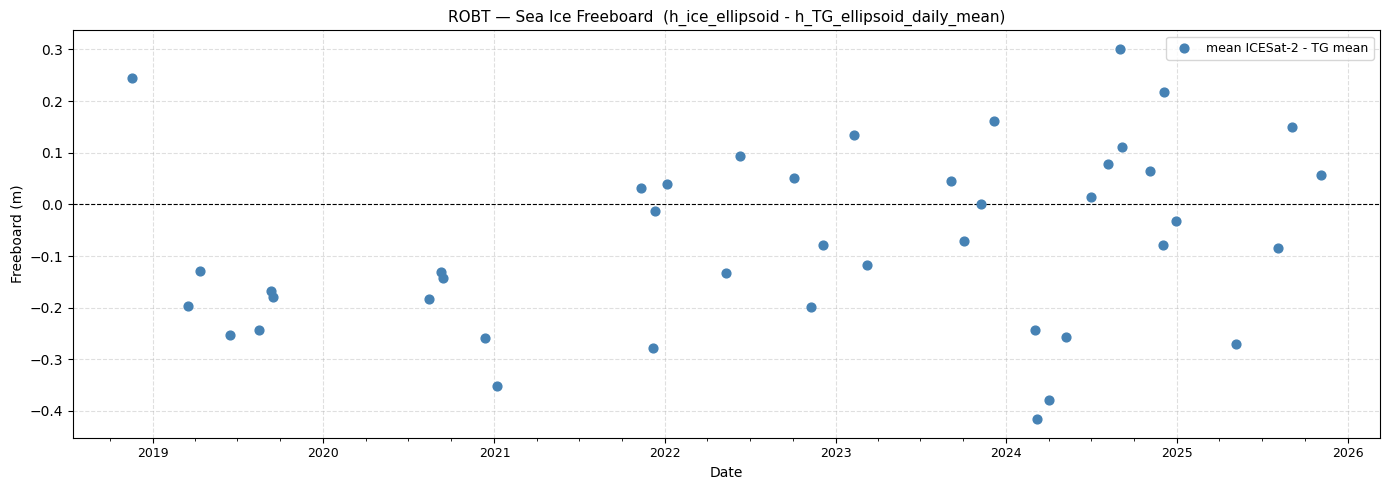

Figure saved -> /home/pzhang27/workspace/Freeboard/output/ROBT_freeboard_timeseries.png


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

ICESAT_OUT_DIR = r'/home/pzhang27/workspace/Freeboard/output'

# ── Load ICESat-2 ROBT segments ───────────────────────────────────────────
df_ice = pd.read_csv(
    os.path.join(ICESAT_OUT_DIR, 'ICESat2_h_ellipsoid_all_stations.csv'),
    parse_dates=['date']
)
df_ice_robt = df_ice[df_ice['station'] == 'ROBT'].copy()
df_ice_robt['date_only'] = df_ice_robt['date'].dt.date

# ── Load tide gauge ROBT (already in ellipsoid height) ───────────────────
df_tg = pd.read_csv(
    r'/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/robt/outliers_removed_ellipsoid.csv',
    parse_dates=['time']
)
df_tg['date_only'] = df_tg['time'].dt.date
tg_daily_mean = df_tg.groupby('date_only')['h_ellipsoid'].mean()

# ── Compute daily ICESat-2 statistics and freeboard ───────────────────────
rows = []
for date, grp in df_ice_robt.groupby('date_only'):
    if date not in tg_daily_mean.index:
        continue
    h_vals = grp['h_ellipsoid'].dropna()
    if len(h_vals) == 0:
        continue
    tg_mean = tg_daily_mean[date]
    rows.append({
        'date'       : pd.Timestamp(date),
        'n_segments' : len(h_vals),
        'ice_mean'   : h_vals.mean(),
        'tg_mean'    : tg_mean,
        'fb_mean'    : h_vals.mean() - tg_mean,
    })

df_fb = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)
print(f'Overlapping days: {len(df_fb)}')
print(df_fb[['date','n_segments','tg_mean','ice_mean','fb_mean']].to_string(index=False))

# ── Save ─────────────────────────────────────────────────────────────────
out_csv = os.path.join(ICESAT_OUT_DIR, 'ROBT_freeboard.csv')
df_fb.to_csv(out_csv, index=False, float_format='%.6f')
print(f'Saved -> {out_csv}')

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(df_fb['date'], df_fb['fb_mean'], marker='o', s=40, color='steelblue', label='mean ICESat-2 - TG mean', zorder=3)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Freeboard (m)', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.set_title('ROBT — Sea Ice Freeboard  (h_ice_ellipsoid - h_TG_ellipsoid_daily_mean)',
             fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
ax.legend(fontsize=9)

plt.tight_layout()
out_fig = os.path.join(ICESAT_OUT_DIR, 'ROBT_freeboard_timeseries.png')
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {out_fig}')


### D4b. Freeboard calculation — SCOT

For each ICESat-2 overpass day that has overlapping tide gauge data:
```
freeboard = h_ice_ellipsoid  -  h_TG_ellipsoid_daily_mean
```
Three estimates of h_ice per day: **mean**, **median**, **2nd percentile** (P02 — proxy for local sea surface level among ice segments).


Overlapping days: 5
      date  n_segments    tg_mean   ice_mean   fb_mean
2019-12-03        5957 -54.282314 -54.276407  0.005907
2020-01-01        1146 -54.286859 -54.203376  0.083484
2020-11-19        1864 -54.209000 -54.224479 -0.015479
2020-11-30        4701 -54.080342 -54.337585 -0.257244
2022-11-15        3428 -54.025236 -54.444954 -0.419718
Saved -> /home/pzhang27/workspace/Freeboard/output/SCOT_freeboard.csv


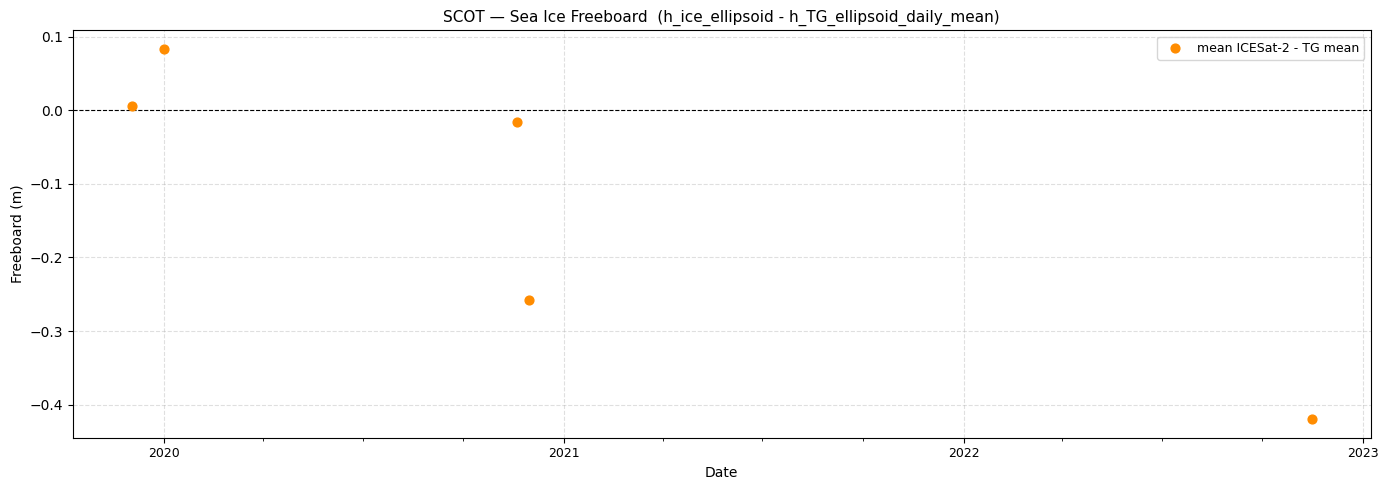

Figure saved -> /home/pzhang27/workspace/Freeboard/output/SCOT_freeboard_timeseries.png


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

ICESAT_OUT_DIR = r'/home/pzhang27/workspace/Freeboard/output'

# ── Load ICESat-2 SCOT segments ───────────────────────────────────────────
df_ice = pd.read_csv(
    os.path.join(ICESAT_OUT_DIR, 'ICESat2_h_ellipsoid_all_stations.csv'),
    parse_dates=['date']
)
df_ice_scot = df_ice[df_ice['station'] == 'SCOT'].copy()
df_ice_scot['date_only'] = df_ice_scot['date'].dt.date

# ── Load tide gauge SCOT (already in ellipsoid height) ───────────────────
df_tg = pd.read_csv(
    r'/media/pzhang27/Extreme SSD/Freeboard_input_data/tide_gauge/scot/outliers_removed_ellipsoid.csv',
    parse_dates=['time']
)
df_tg['date_only'] = df_tg['time'].dt.date
tg_daily_mean = df_tg.groupby('date_only')['h_ellipsoid'].mean()

# ── Compute daily ICESat-2 statistics and freeboard ───────────────────────
rows = []
for date, grp in df_ice_scot.groupby('date_only'):
    if date not in tg_daily_mean.index:
        continue
    h_vals = grp['h_ellipsoid'].dropna()
    if len(h_vals) == 0:
        continue
    tg_mean = tg_daily_mean[date]
    rows.append({
        'date'       : pd.Timestamp(date),
        'n_segments' : len(h_vals),
        'ice_mean'   : h_vals.mean(),
        'tg_mean'    : tg_mean,
        'fb_mean'    : h_vals.mean() - tg_mean,
    })

df_fb = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)
print(f'Overlapping days: {len(df_fb)}')
print(df_fb[['date','n_segments','tg_mean','ice_mean','fb_mean']].to_string(index=False))

# ── Save ─────────────────────────────────────────────────────────────────
out_csv = os.path.join(ICESAT_OUT_DIR, 'SCOT_freeboard.csv')
df_fb.to_csv(out_csv, index=False, float_format='%.6f')
print(f'Saved -> {out_csv}')

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(df_fb['date'], df_fb['fb_mean'], marker='o', s=40, color='darkorange', label='mean ICESat-2 - TG mean', zorder=3)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Freeboard (m)', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.set_title('SCOT — Sea Ice Freeboard  (h_ice_ellipsoid - h_TG_ellipsoid_daily_mean)',
             fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
ax.legend(fontsize=9)

plt.tight_layout()
out_fig = os.path.join(ICESAT_OUT_DIR, 'SCOT_freeboard_timeseries.png')
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {out_fig}')
